In [5]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from astropy.cosmology import Planck18

In [6]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using linear bias $b=\sqrt{\xi_{qq}/\xi_{mm}}$
## Define a function

In [7]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [8]:
def bias(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

## Parameters

In [9]:
G_hi = 20.5
G_lo = 20.0

In [10]:
nthreads = 18

In [11]:
# # cosmology 1
# h=0.6844
# Omega_m = 0.302

# # cosmology 2
# Omega_m_quaia = 0.343
# h_quaia = 0.674

In [12]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [13]:
# H0 = h*100 * u.km/u.s/u.Mpc
# rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

# H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
# rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [14]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [15]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [16]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rpmin), np.log10(rpmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [17]:
pimax = 80 # 40 # 5000.0 # 40.0

In [18]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [19]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [20]:
# Omega_c = 0.2513
# Omega_b = 0.048
# Omega_m_planck = Omega_c+Omega_b
# cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
#                           h=h, n_s=0.95, sigma8=0.8)
# cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
#                           h=h_quaia, n_s=0.95, sigma8=0.766)

In [21]:
# Omega_m_planck20 = 0.315

In [22]:
# cosmo_planck20 = ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=0.674, n_s=0.95, sigma8=0.8)

In [23]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value,
                               m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [24]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [25]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
colors = [orange, green]

In [26]:
# labels = ['Planck18', 'Quaia23']
# labels = ['Planck20', 'Quaia23']

# Use a 50th percentile mask
## For $\xi(s)$

In [27]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [28]:
# Omega_m_array = [Omega_m_planck20, Omega_m_quaia]
# h_array = [cosmo_planck20['h'], h_quaia]
# cosmos = [cosmo_planck20, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = [], []
yerr_cf, b_cf = [], []
# for i in range(len(Omega_m_array)):
H0 = cosmo_planck18['H0'] * u.km/u.s/u.Mpc
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = cosmo_planck18['Omega_m'], h = cosmo_planck18['h'], error = True)
    cf_zbin_percentile.append(cf)

    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a_median(tab_datahi_mask_zbin0))
    cf_matter_zbin_percentile.append(cf_matter)

    b = np.sqrt(cf/cf_matter)
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849

    yerr_cf.append(yerr)
    b_cf.append(b)

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1963488981.py:25: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_230519/1963488981.py:26: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_230519/1963488981.py:27: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1963488981.py:25: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_230519/1963488981.py:26: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_230519/1963488981.py:27: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1963488981.py:25: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_230519/1963488981.py:26: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1963488981.py:25: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_230519/1963488981.py:26: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_230519/1963488981.py:27: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849


## Implement Poisson error bars as $\Delta \xi(s)=\frac{1+\xi(s)}{\sqrt{DD(s)}}$ 
### Use $\Delta \xi(s)=\sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}}$ if $\xi(s)<0$

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/341221453.py:17: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j],


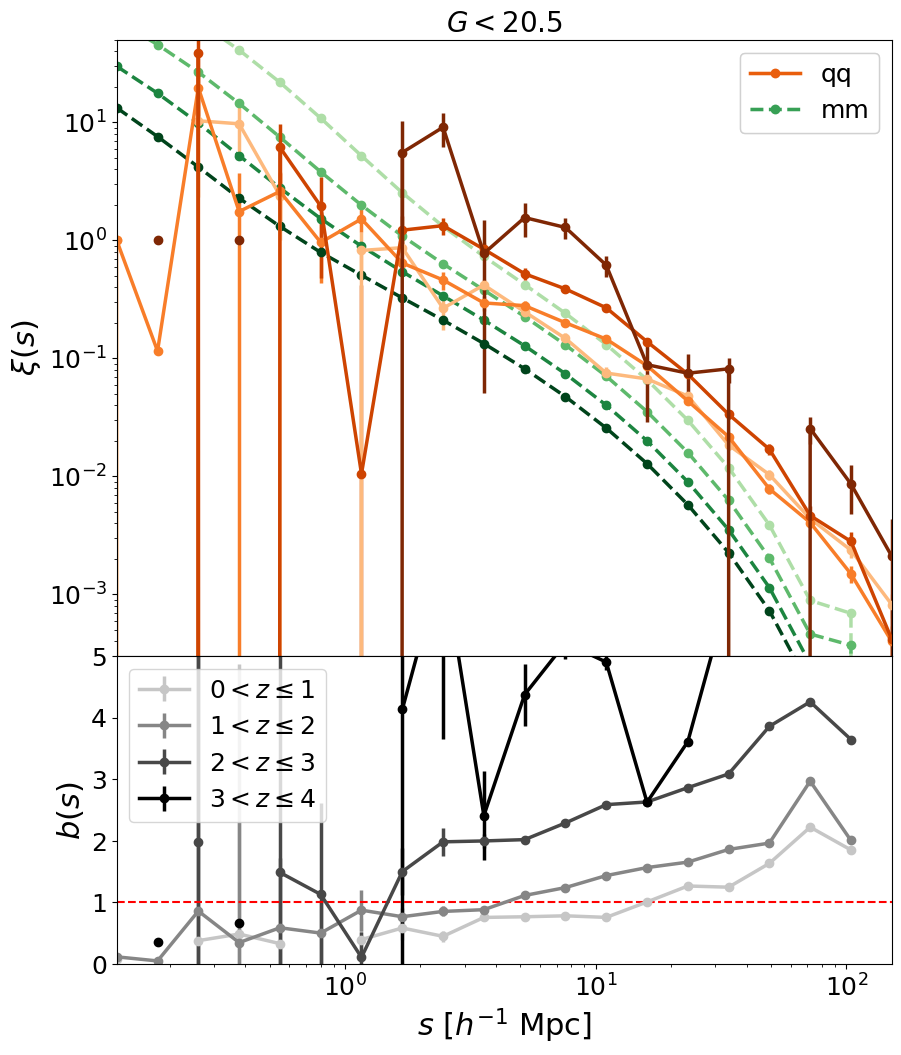

In [29]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array:
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, 
             marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], 
                 yerr = yerr_cf[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 5)
ax2.legend()

# if i == 0:
ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/3693022110.py:20: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j])
/tmp/ipykernel_230519/3693022110.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


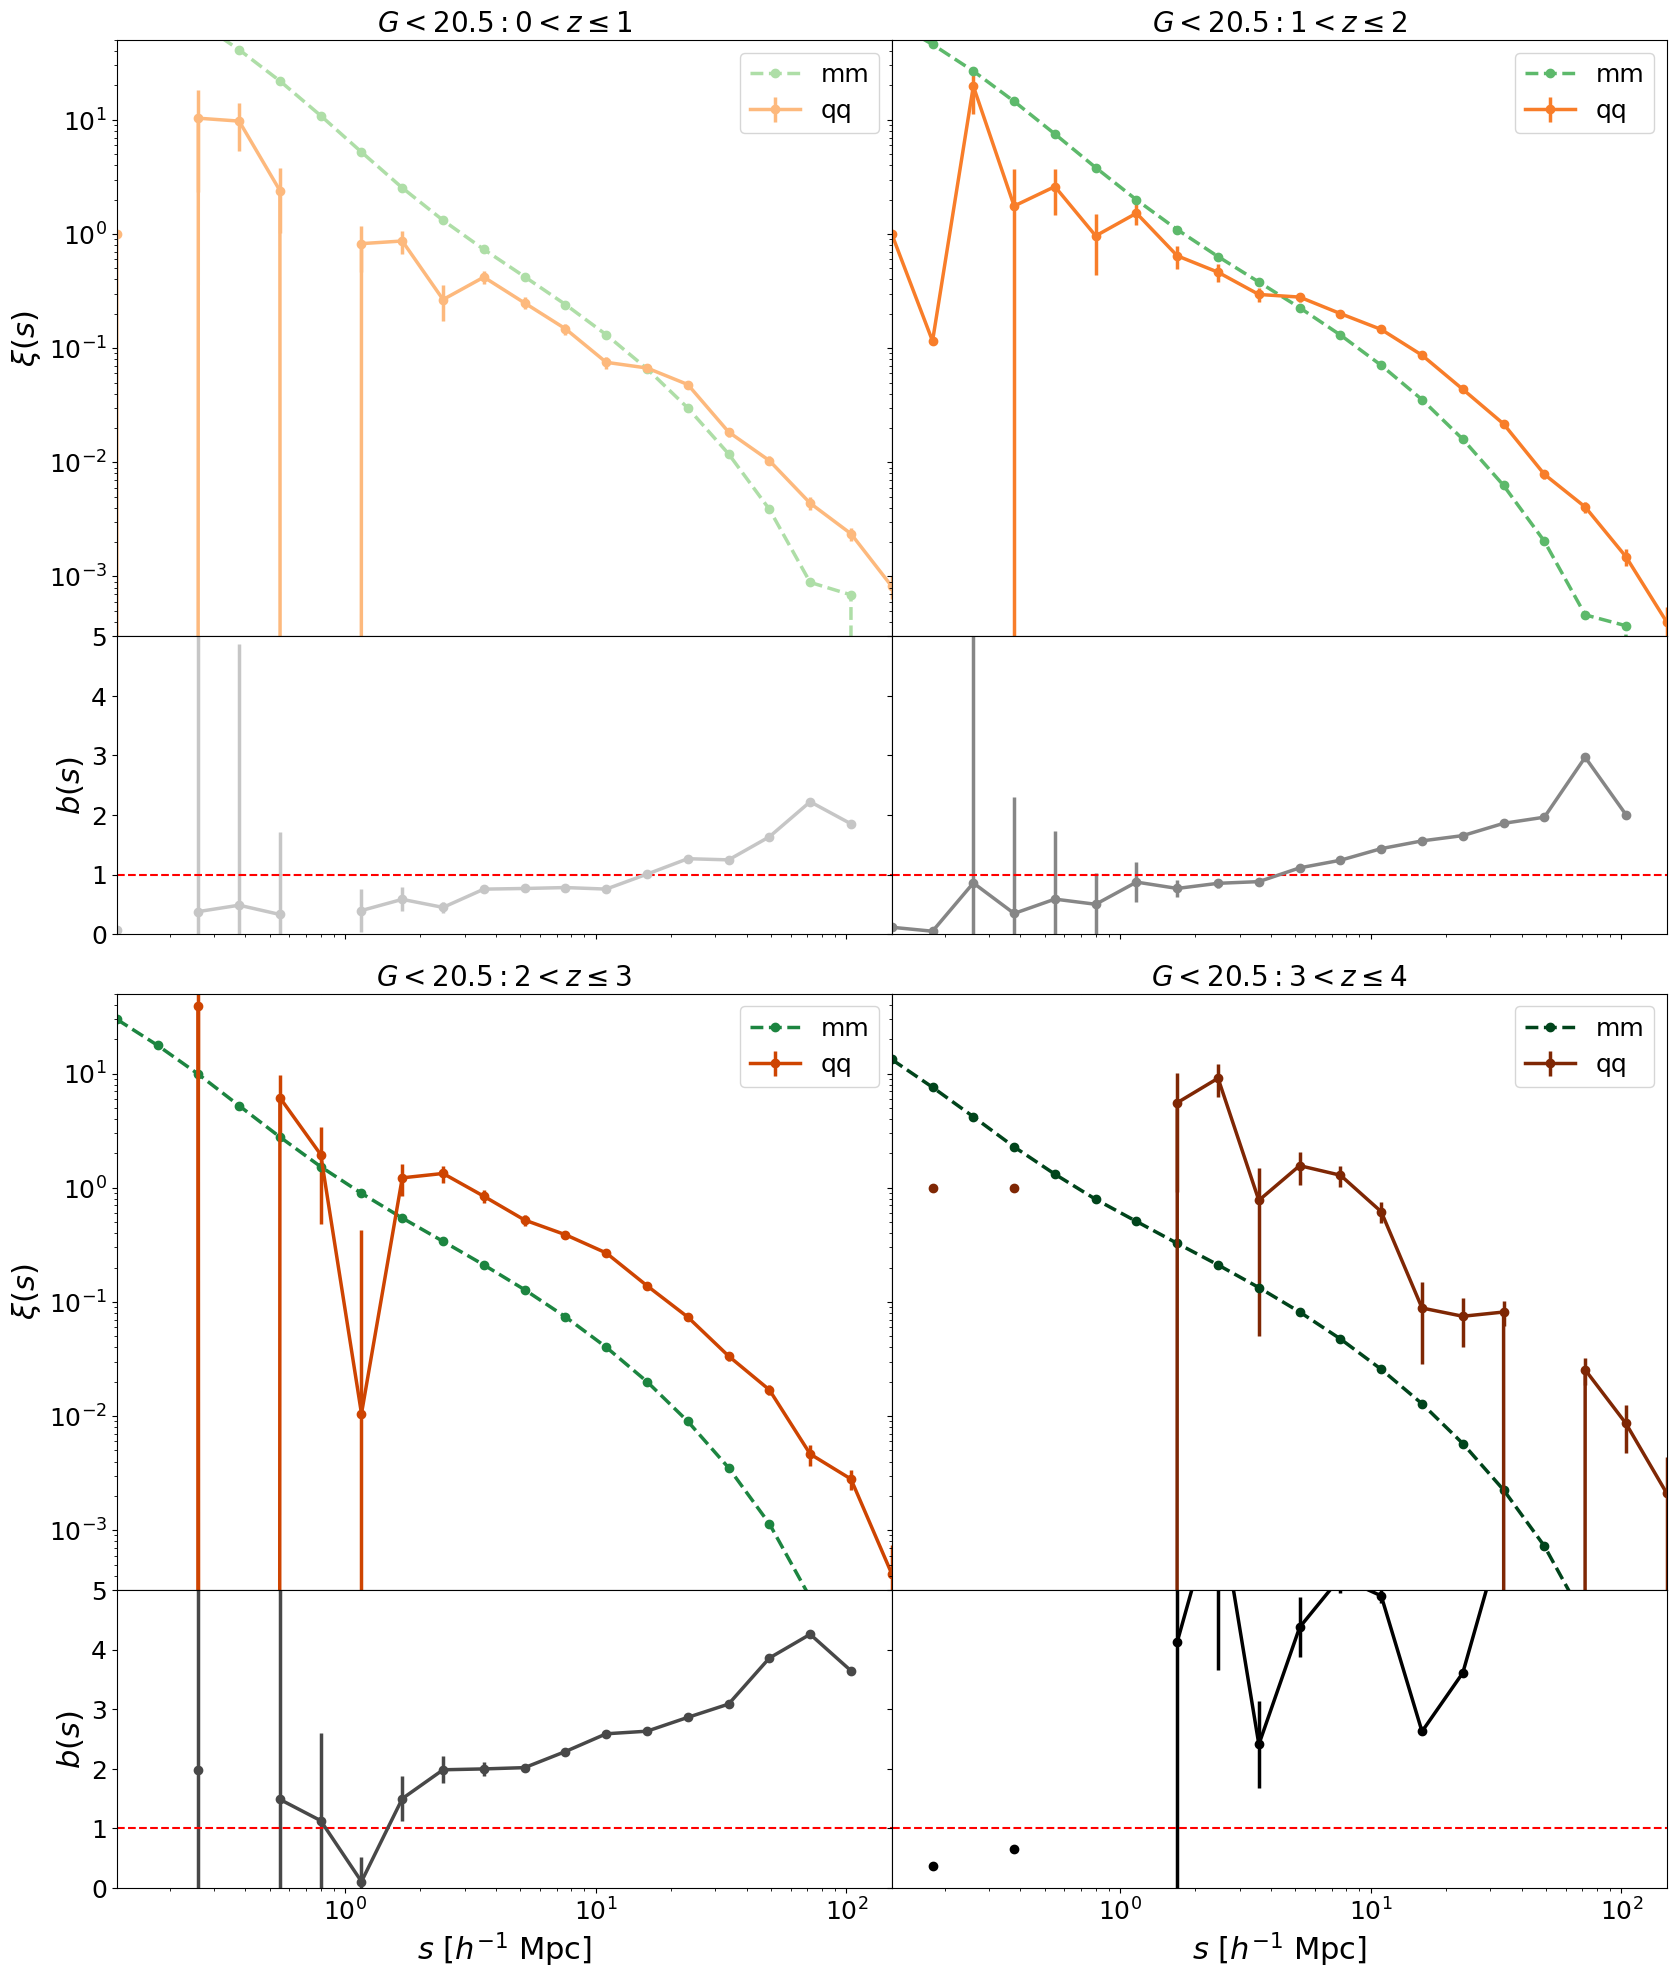

In [30]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
        
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, yerr = yerr_cf[j],
             marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    # if j == 0:
    #     custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
    #                     Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
    #     second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    #     ax1.add_artist(second_legend)

    # patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    # first_legend = ax1.legend(handles=patch, loc = 'lower left')
    # ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4
        
    ax1.legend()
    
plt.show()

## For $w_p(r_p)$

In [31]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [32]:
# Omega_m_array = [Omega_m, Omega_m_quaia]
# h_array = [h, h_quaia]
# cosmos = [cosmo, cosmo_quaia]
# linestyles = ['-', '--']
# H0_array = [H0, H0_quaia]

wp_zbin_percentile, wp_matter_zbin_percentile = [], []
rpavg_zbin_percentile = []
yerr_wp, b_wp = [], []
# for i in range(len(Omega_m_array)):
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask)
    wp_zbin_i, rpavg_zbin_i, qq, qr = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = cosmo_planck18['Omega_m'], 
                                                  h = cosmo_planck18['h'], nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax, 
                                                  error = True)
    wp_zbin_percentile.append(wp_zbin_i)
    rpavg_zbin_percentile.append(rpavg_zbin_i)

    # version 3
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
    wp_matter_zbin_percentile.append(wp_matter_zbin_i)

    b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
    yerr=(1+wp_zbin_i)/np.sqrt(qq)
    yerr[wp_zbin_i<0]=np.sqrt((1+b**2*wp_matter_zbin_i)/qr)[wp_zbin_i<0] #https://arxiv.org/abs/1603.04849

    yerr_wp.append(yerr)
    b_wp.append(b)

G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1460017262.py:31: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)


G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1460017262.py:31: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)


G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1460017262.py:31: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)


G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_230519/1460017262.py:31: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/494027856.py:18: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])


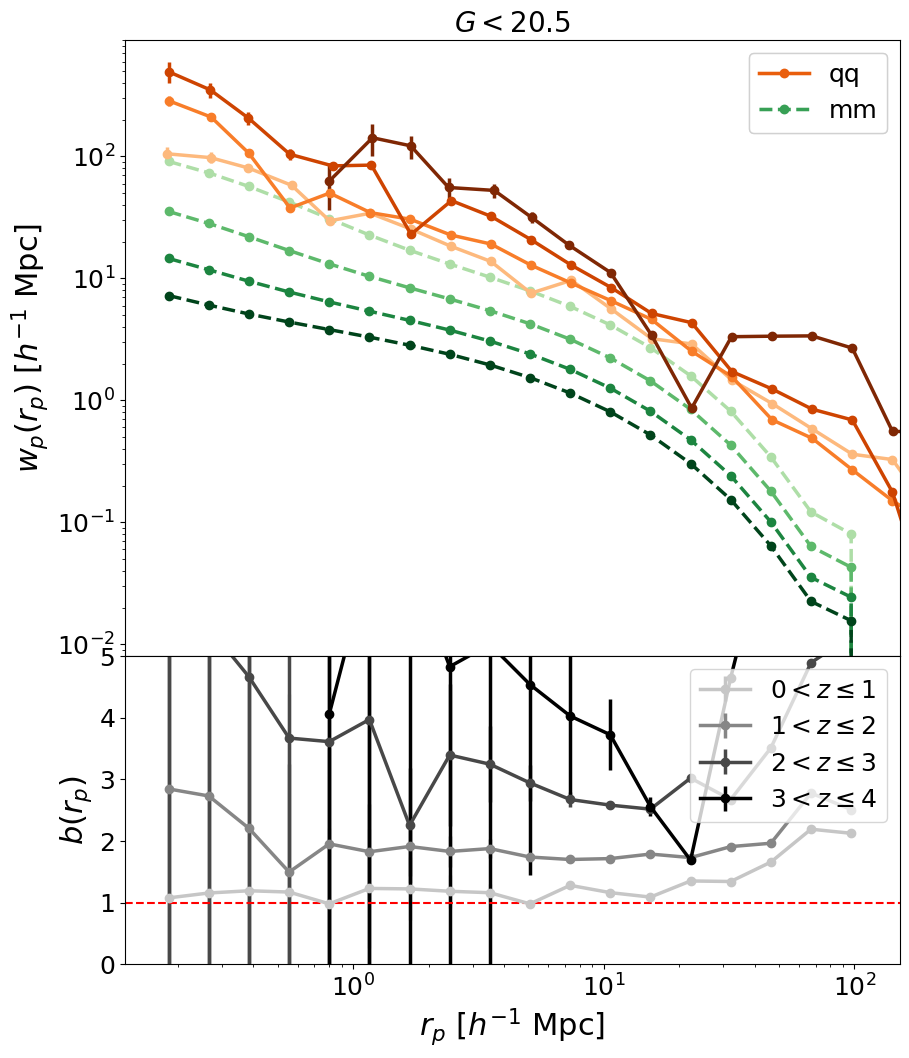

In [33]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array: 

    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), b_wp[j], linewidth = 2.5, 
                 marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(8e-3, 9e2)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 5)
ax2.legend()

# if i == 0:
ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
ax2.set_ylabel(r'$b(r_p)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/3962076710.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rpbins), b_wp[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_230519/3962076710.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


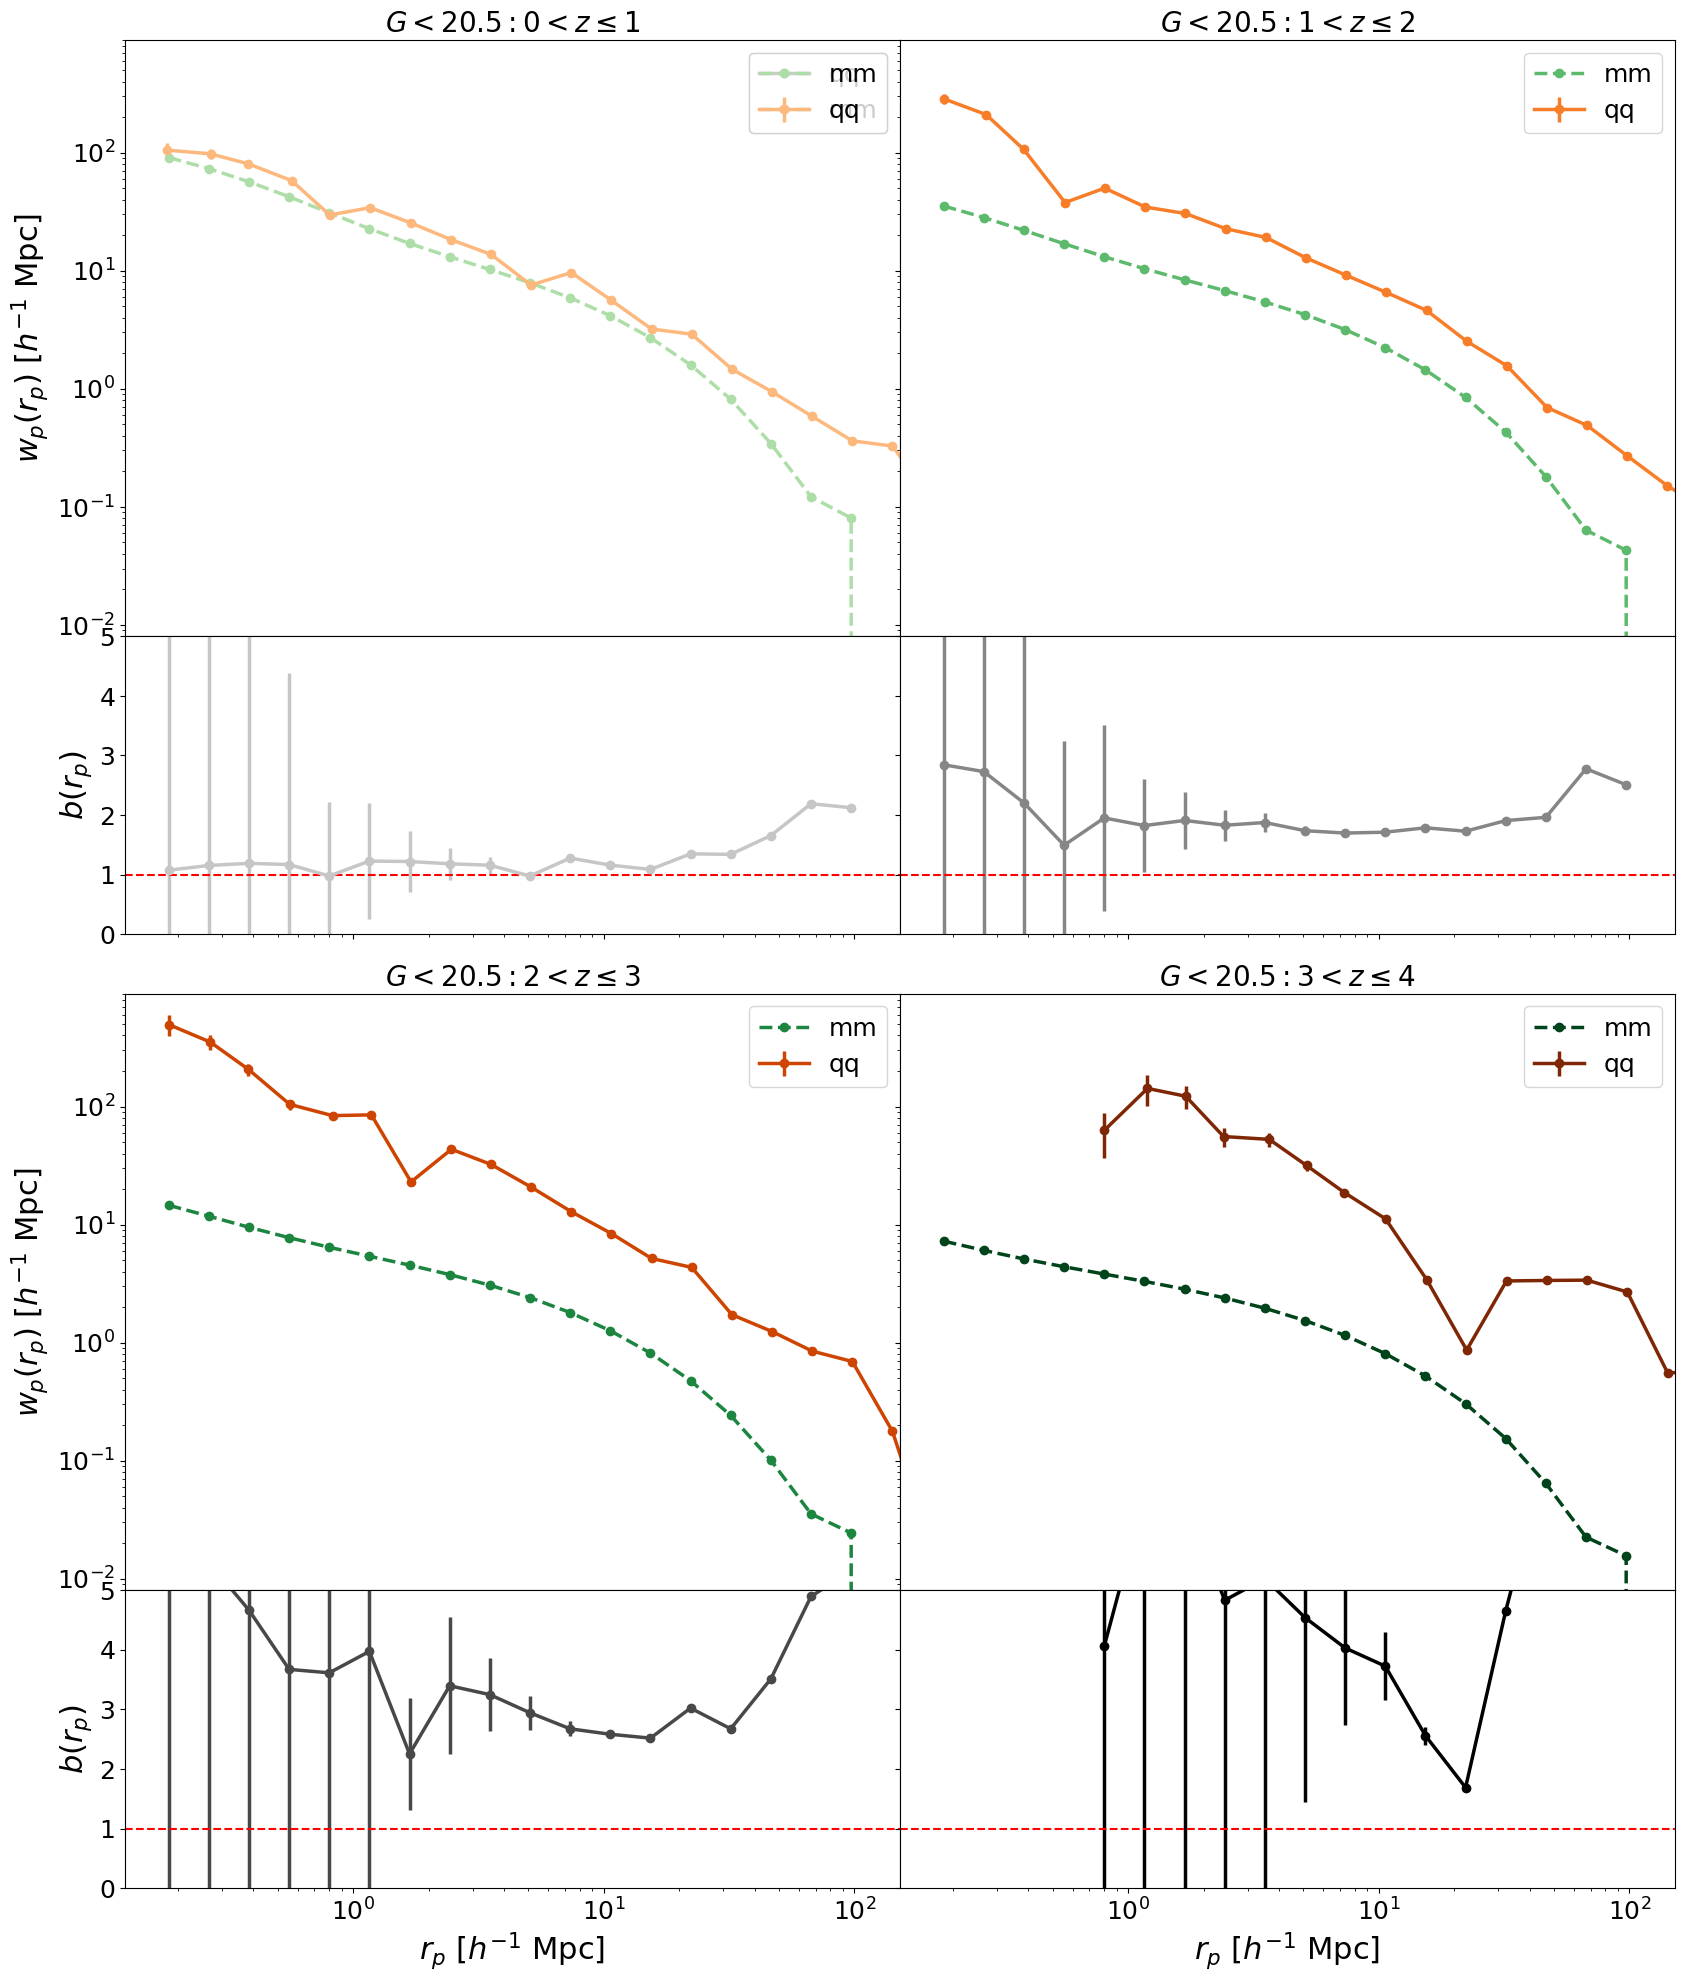

In [34]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
        
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), b_wp[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmap_b[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    # patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    # first_legend = ax1.legend(handles=patch, loc = 'lower left')
    # ax1.add_artist(first_legend)
    ax1.legend()

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/4075227461.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j],
/tmp/ipykernel_230519/4075227461.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rpbins), b_wp[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_230519/4075227461.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))


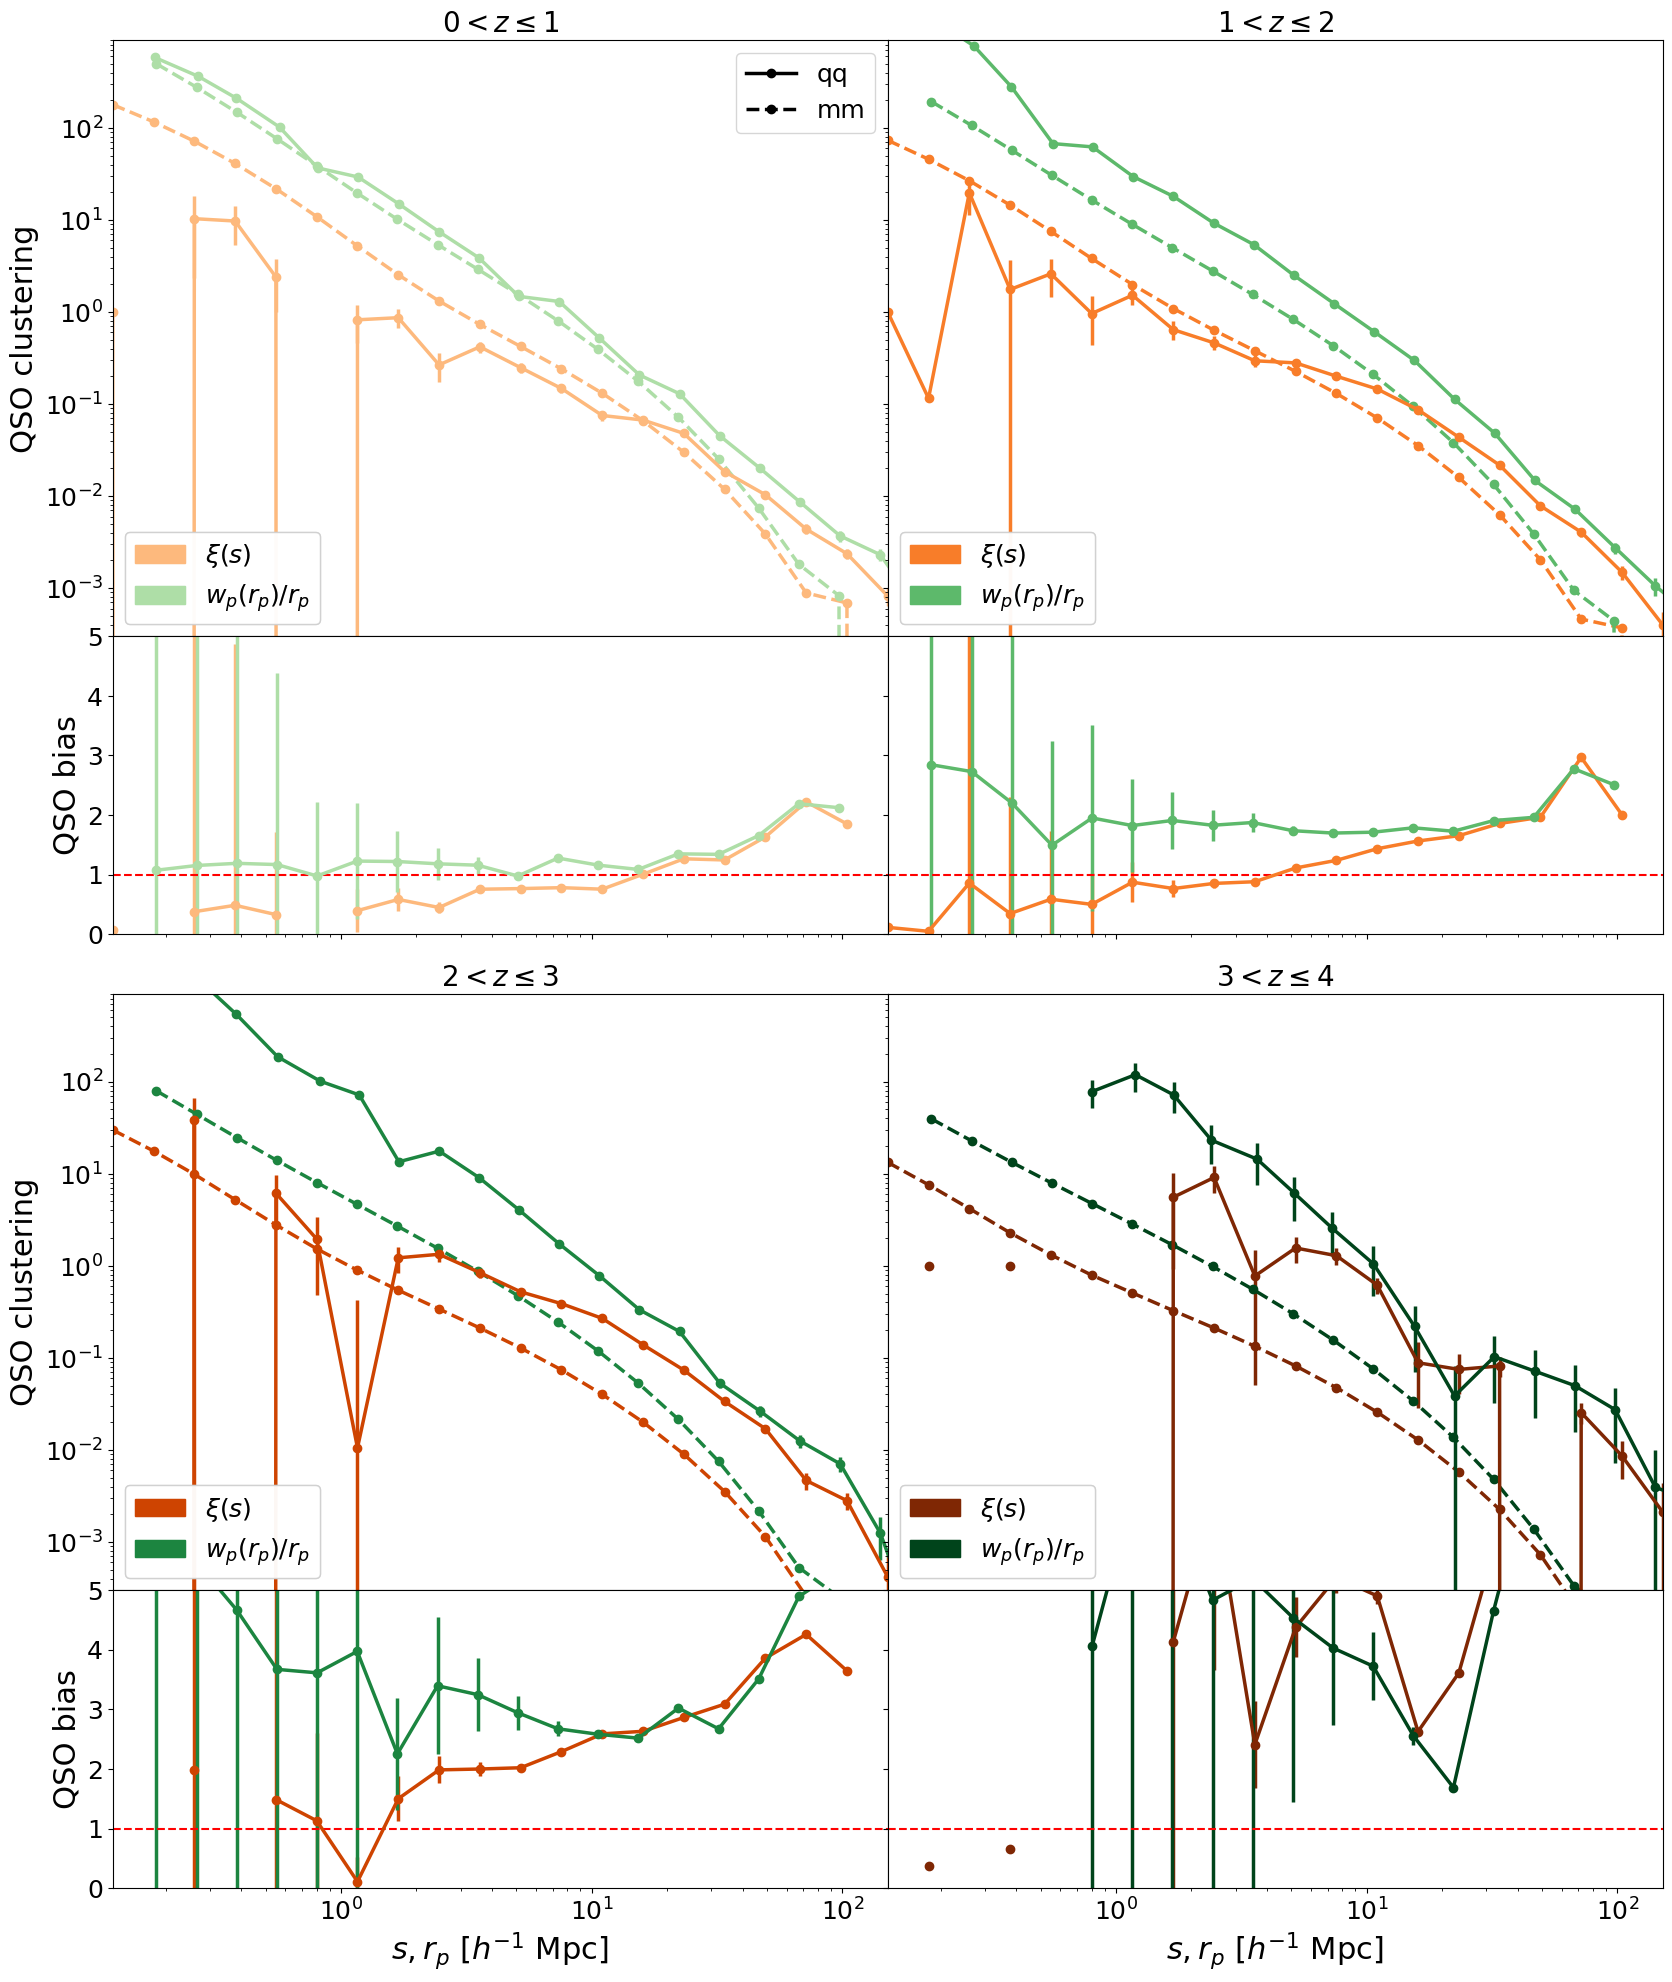

In [35]:
labels_cf = ['qq', 'mm']

# for i in range(len(Omega_m_array)):
    
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], 
                 yerr = yerr_cf[j])

    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j]/rpavg_zbin_percentile[j], linewidth = 2.5, 
                 marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
             color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), b_wp[j], linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                 color = cmap_mm[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', #title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                   title_fontsize = 18, alignment = 'right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels_cf))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'QSO clustering')
        ax2.set_ylabel(r'QSO bias')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])

    if j % 2 != 0:
        k+=4

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [36]:
# Omega_m_array = [Omega_m_planck20, Omega_m_quaia]
# h_array = [cosmo_planck20['h'], h_quaia]
# cosmos = [cosmo_planck20, cosmo_quaia]
# linestyles = ['-', '--']

a_zbin = []
# for i in range(len(Omega_m_array)):
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    a_zbin.append(a_median(tab_datahi_mask_zbin0))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/890337493.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


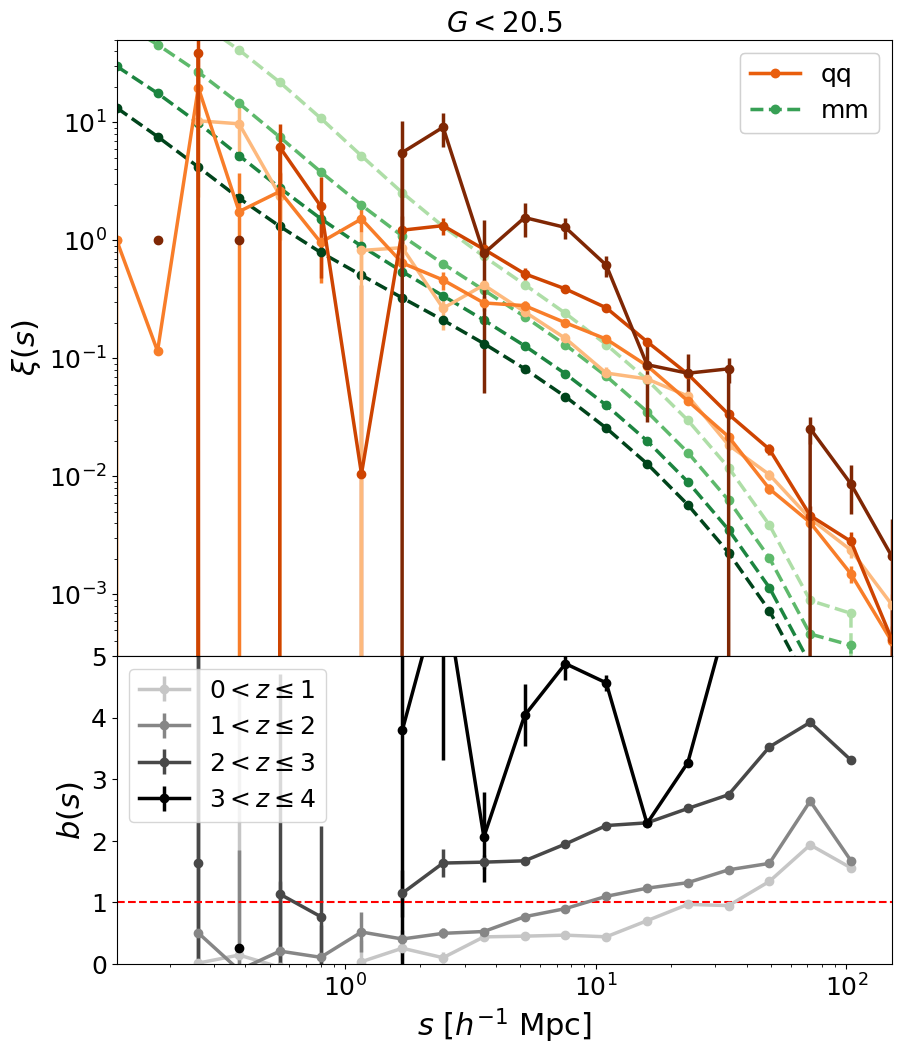

In [37]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), bias(cf_zbin_percentile[j], cf_matter_zbin_percentile[j], 
                                             ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 5)
ax2.legend()

# if i == 0:
ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/1139461035.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


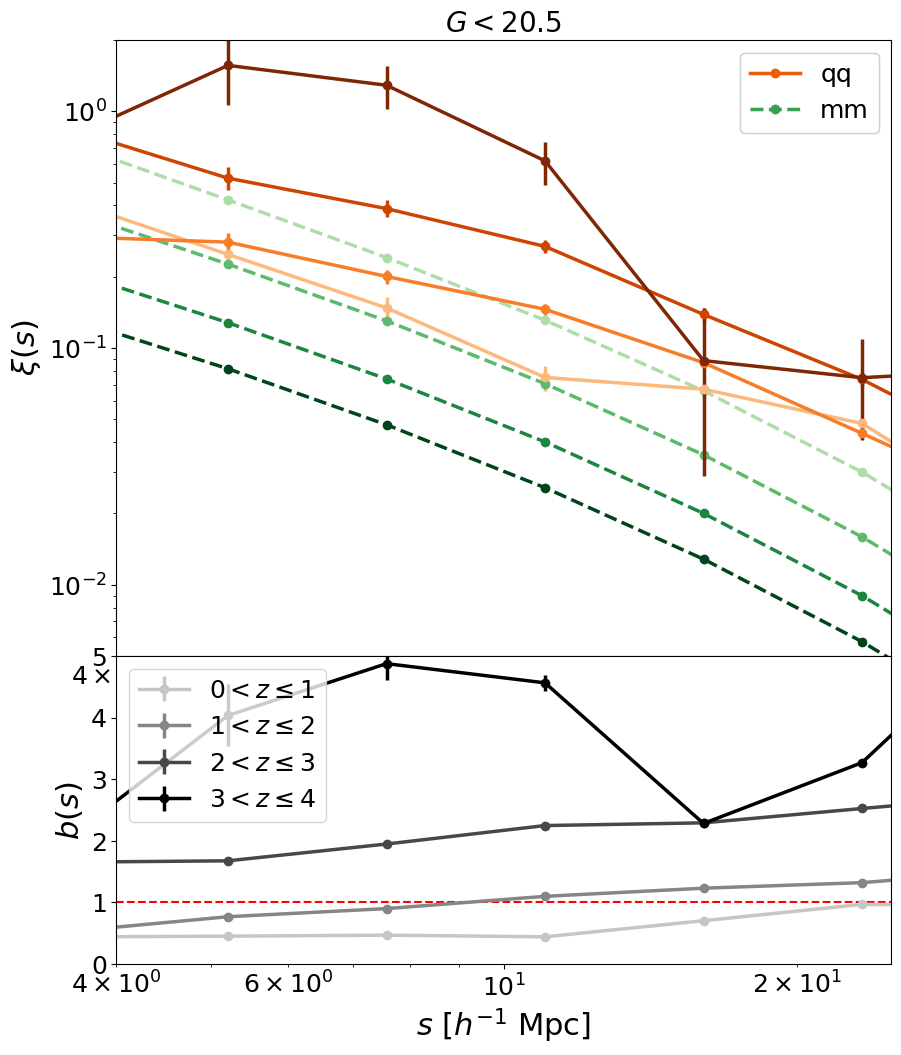

In [38]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j],
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), bias(cf_zbin_percentile[j], cf_matter_zbin_percentile[j], 
                                             ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(4, 25)
ax1.set_ylim(5e-3, 2)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(4, 25)
ax2.set_ylim(0, 5)
ax2.legend()

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

# if i == 0:
ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

ax1.set_xticklabels([])

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/3481827753.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/3481827753.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value enco

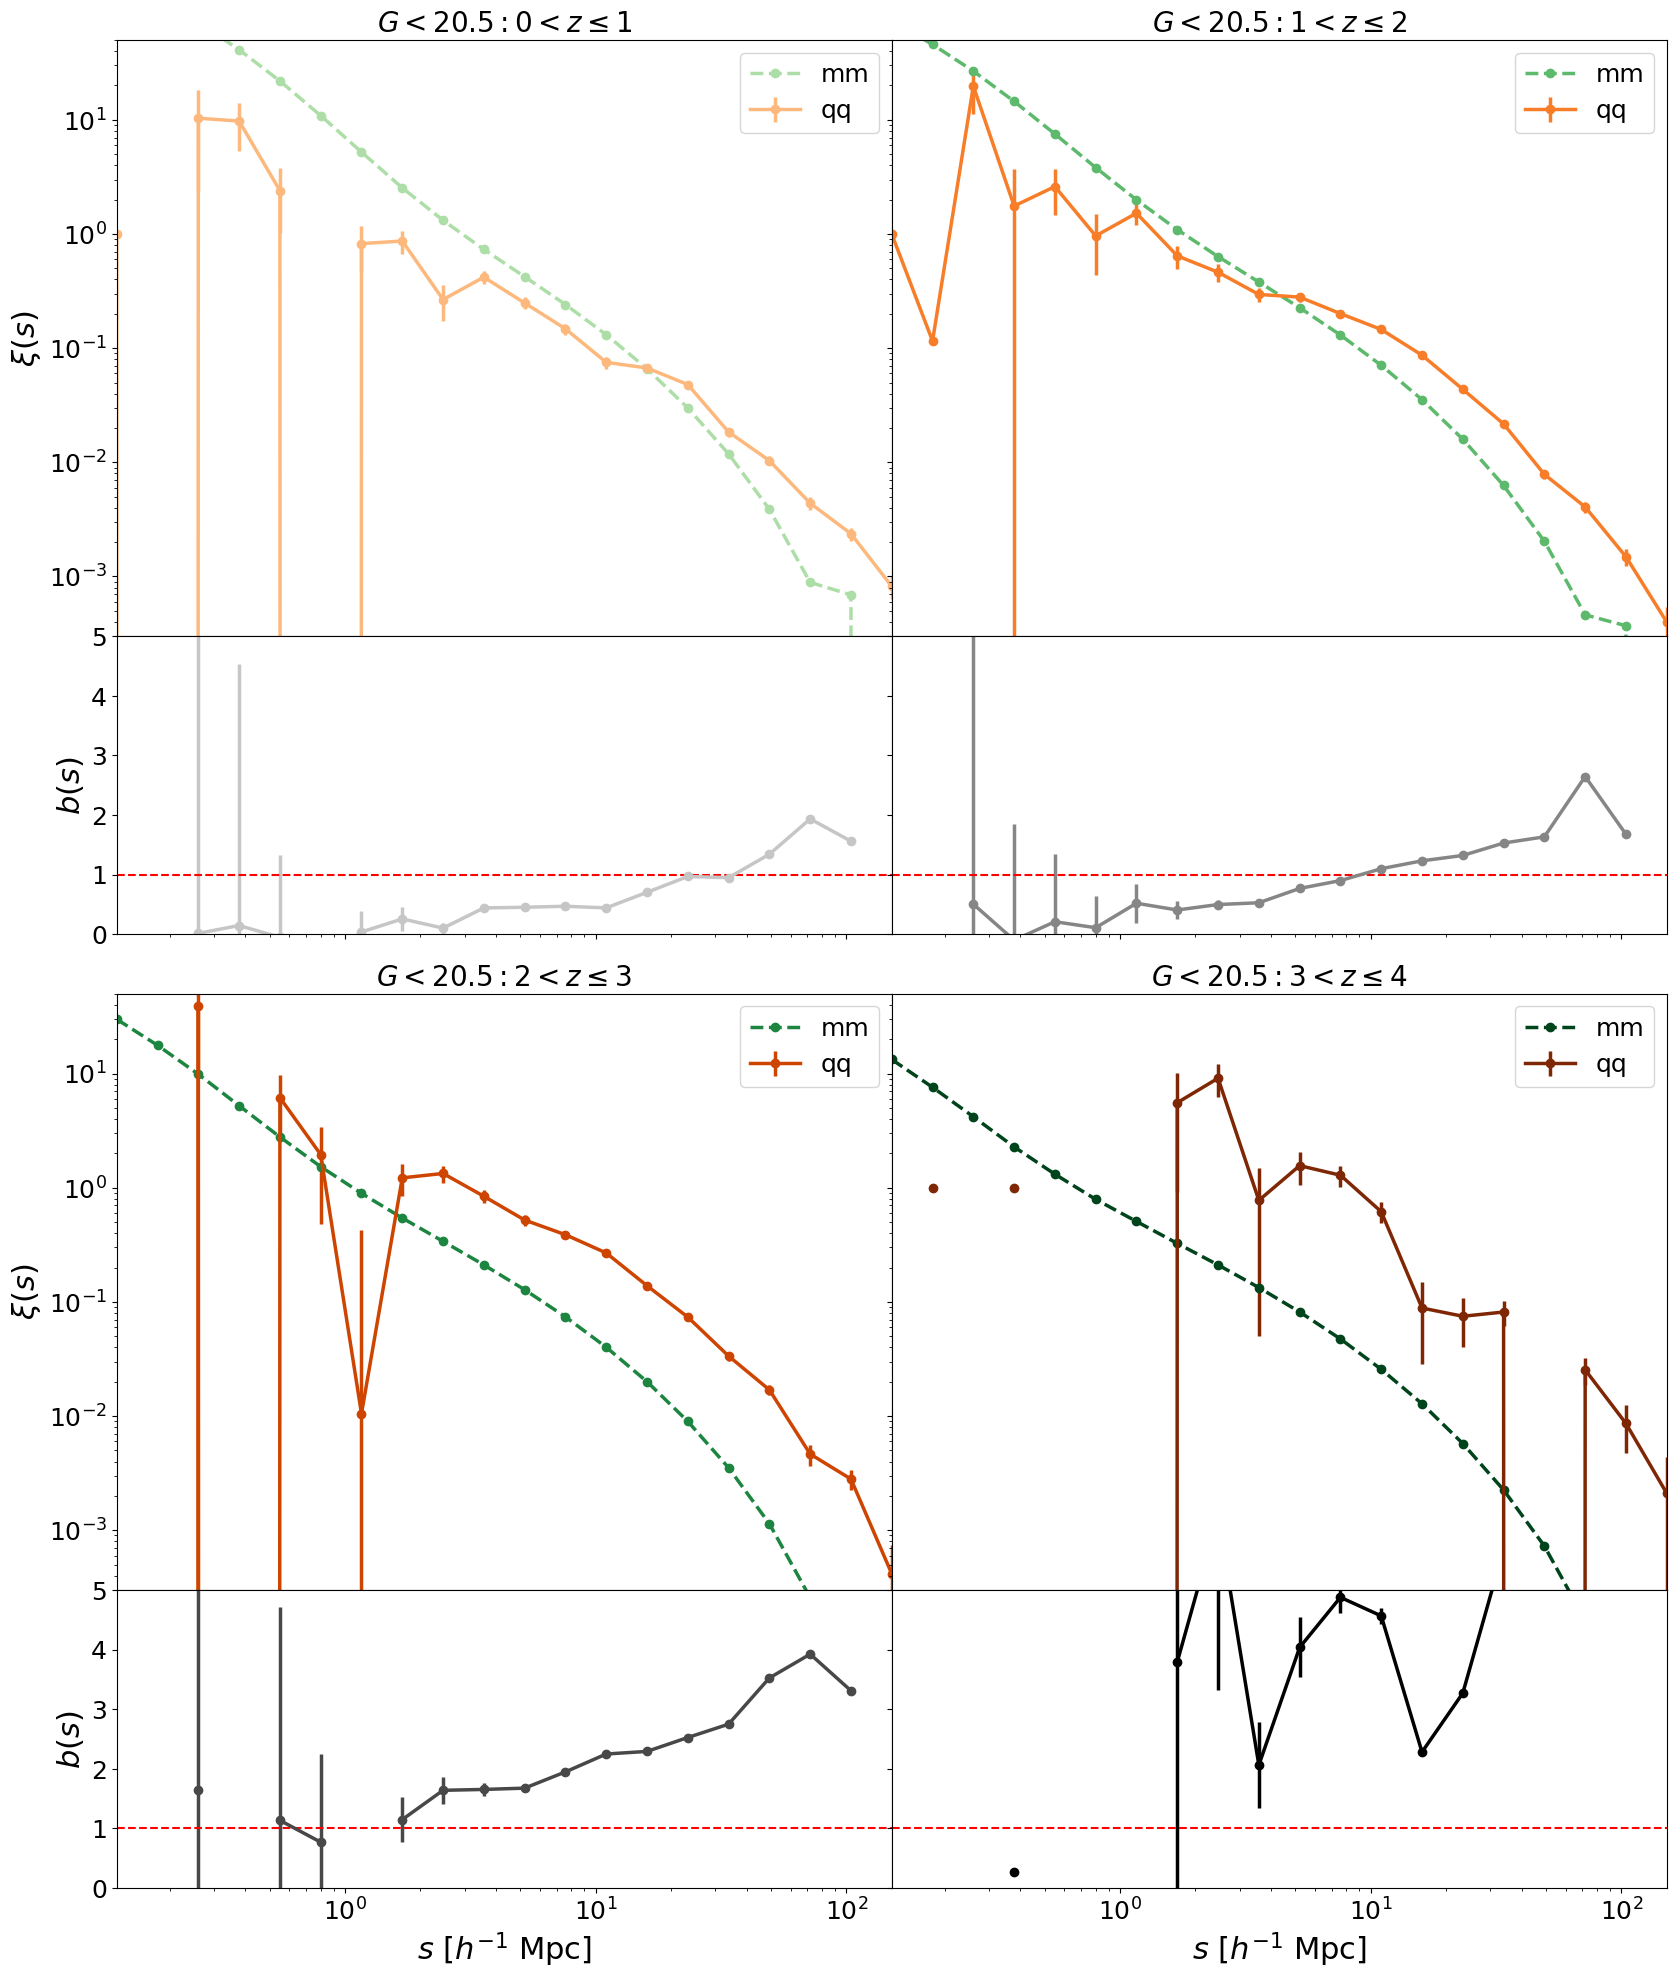

In [39]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
    
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j],
                yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), bias(cf_zbin_percentile[j], cf_matter_zbin_percentile[j], 
                                            ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    # if j == 0:
    #     custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
    #                     Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
    #     second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    #     ax1.add_artist(second_legend)
    ax1.legend()

    # patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    # first_legend = ax1.legend(handles=patch, loc = 'lower left')
    # ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/3396590285.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/3396590285.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value enco

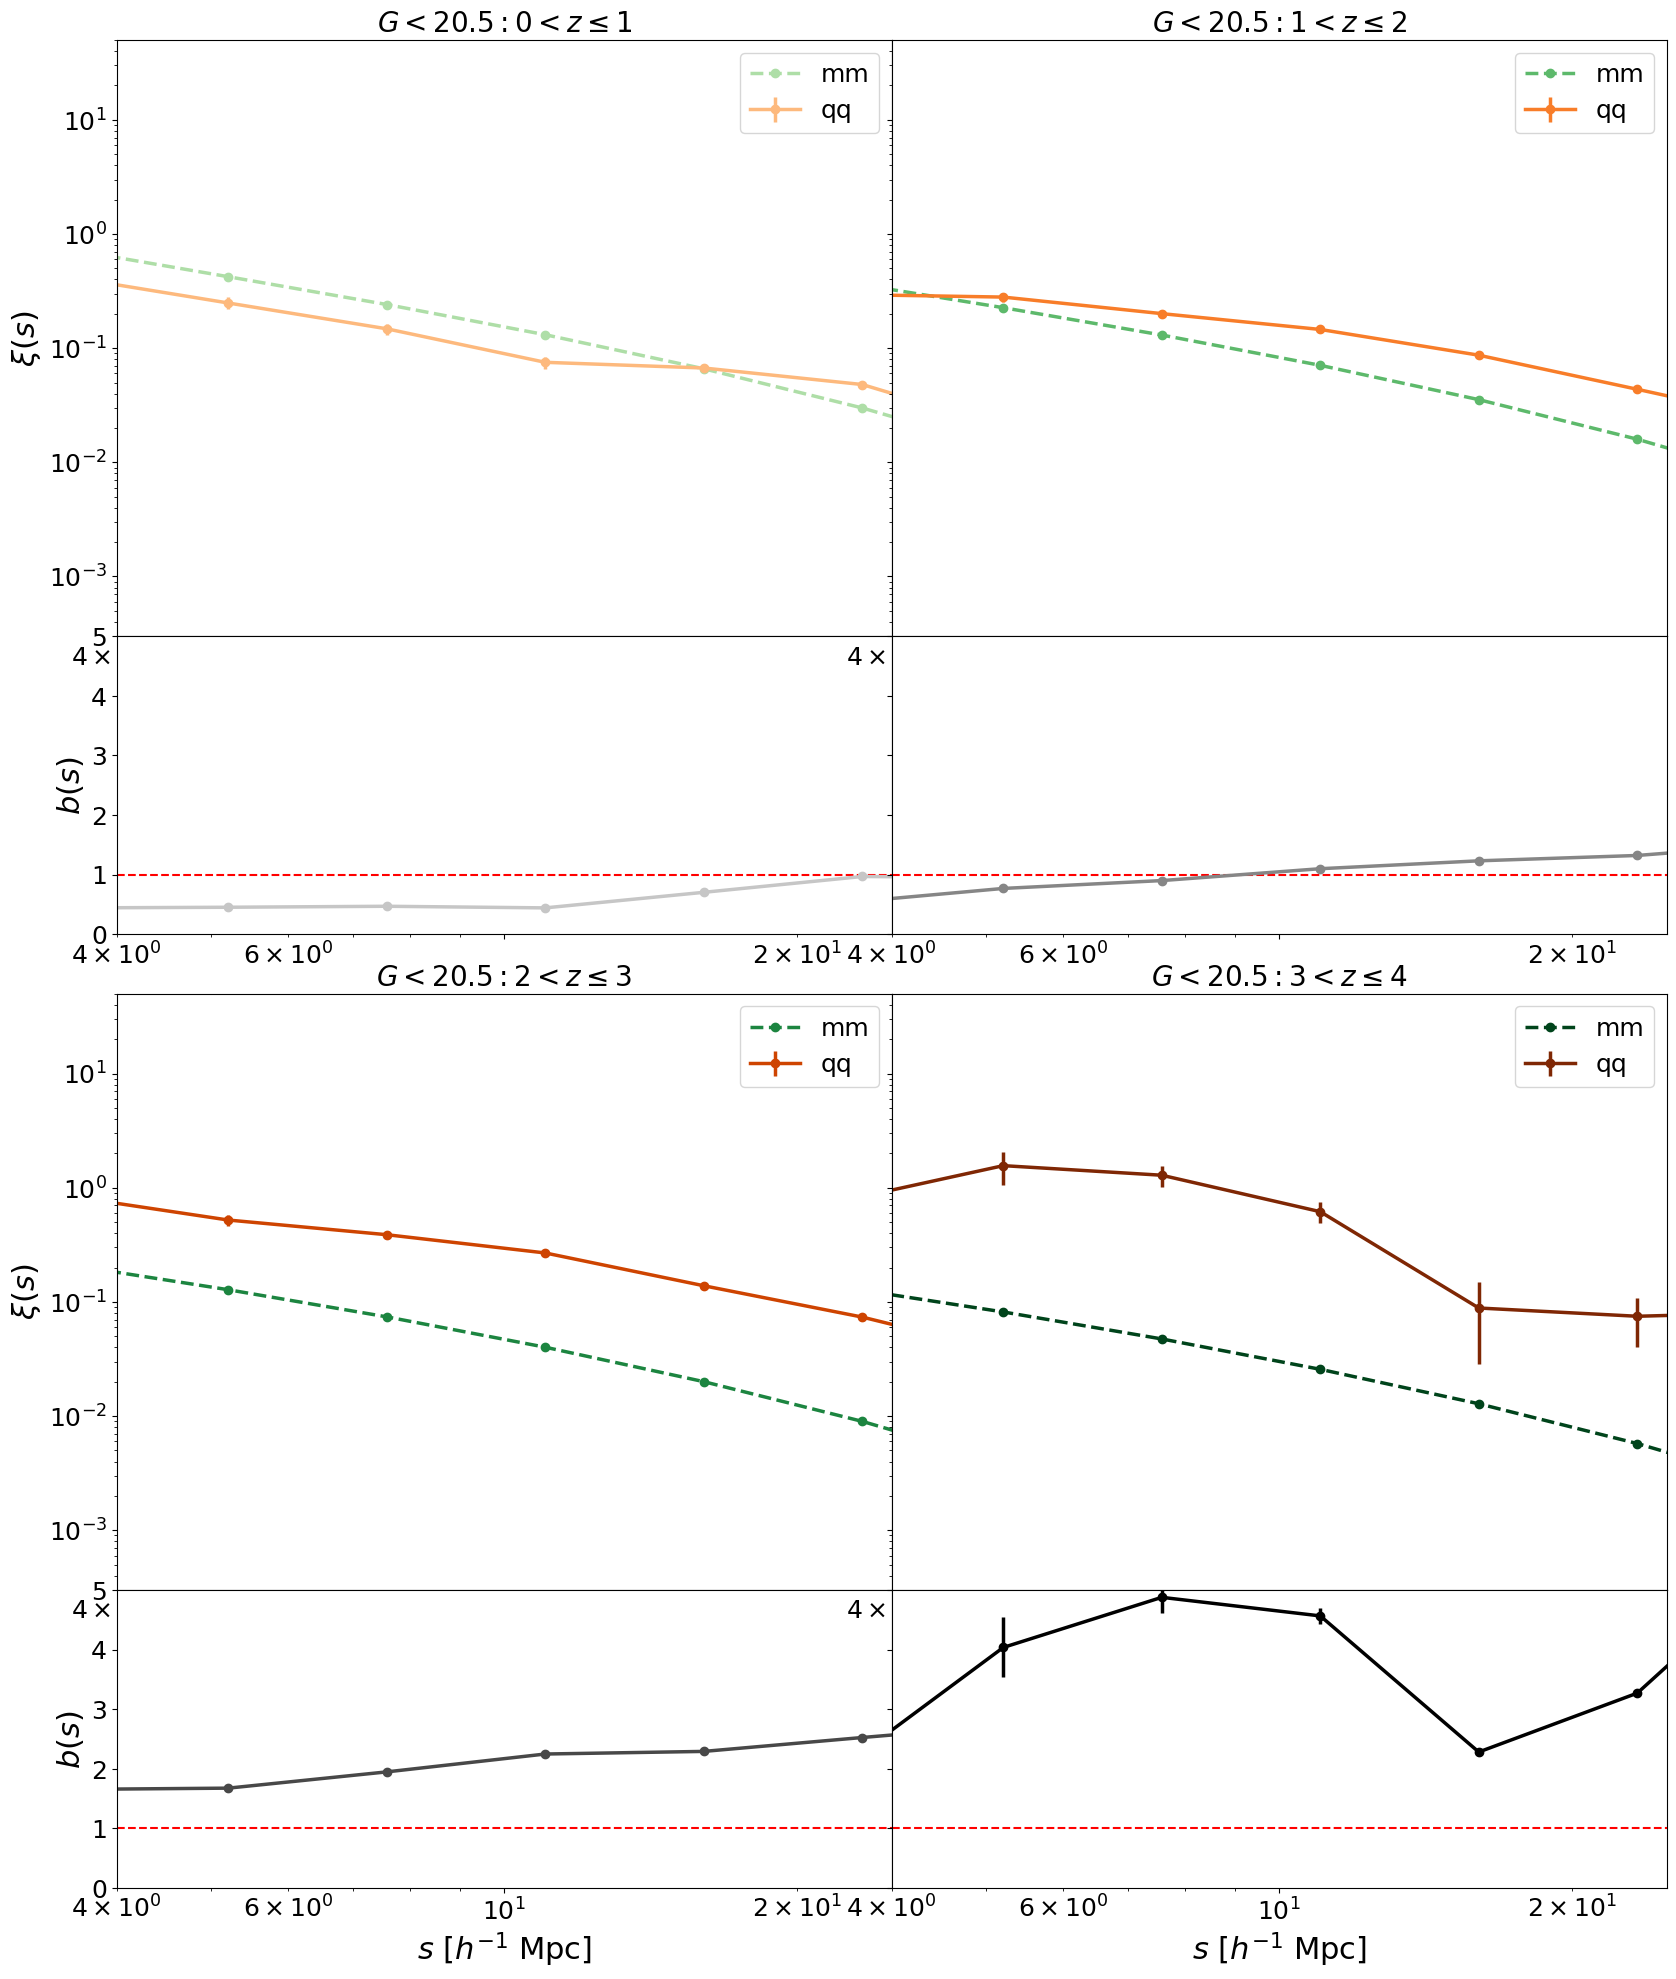

In [40]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
    
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j],
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), bias(cf_zbin_percentile[j], cf_matter_zbin_percentile[j], 
                                            ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o',
                label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_cf[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()
    
#     if j == 0:
#         custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                         Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
#         second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
#         ax1.add_artist(second_legend)

#     patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
#     first_legend = ax1.legend(handles=patch, loc = 'lower left')
#     ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{w^{(s)}_{p,{\mathrm{qq}}}(r_p)}{w^{(r)}_{p,\mathrm{mm}}(r_p)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/892526070.py:18: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr=yerr_wp[j])
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


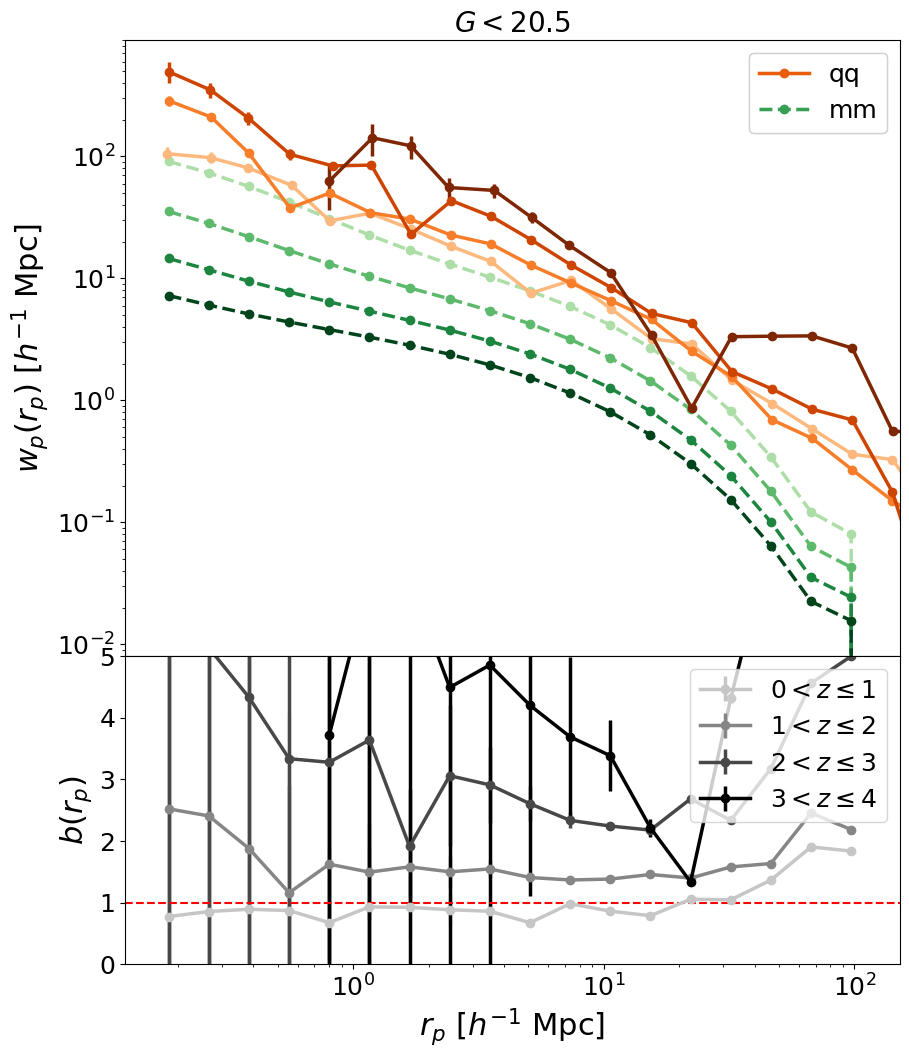

In [41]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array:

    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr=yerr_wp[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(8e-3, 9e2)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 5)
ax2.legend()

# if i == 0:
ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
ax2.set_ylabel(r'$b(r_p)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/1302228339.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


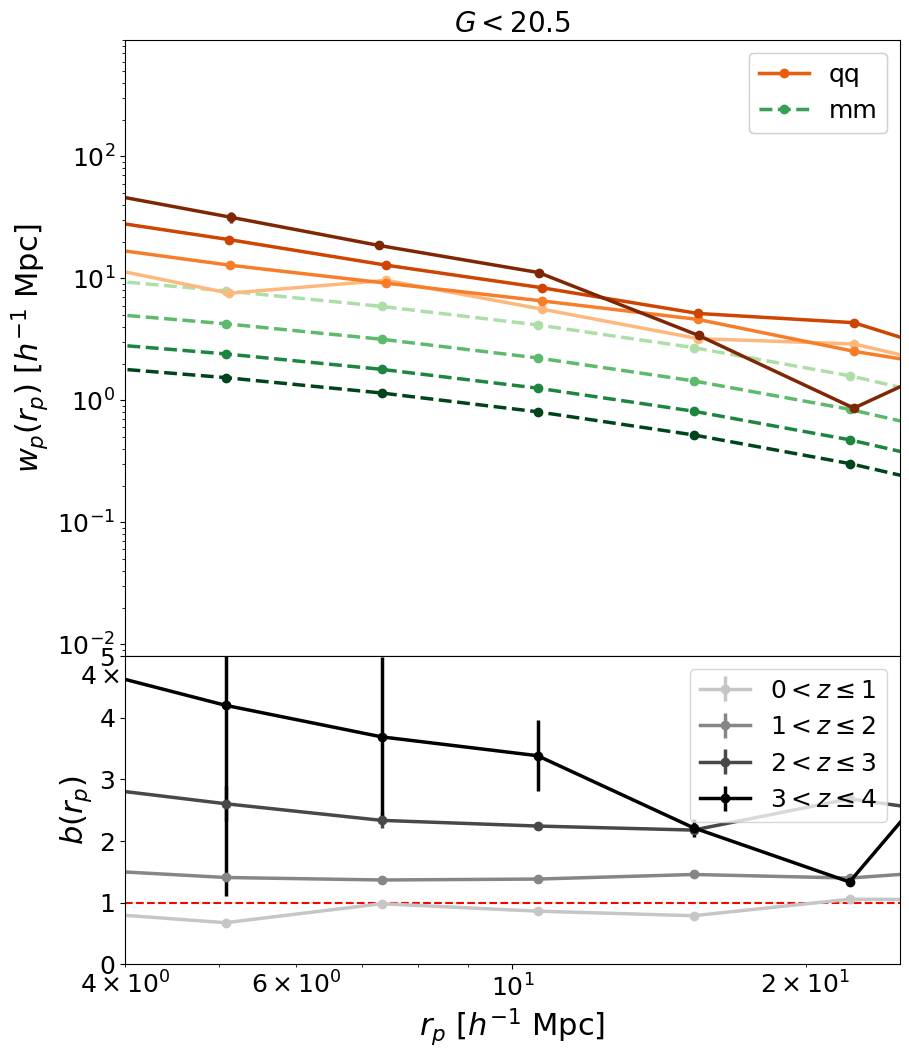

In [42]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
# for i in range(len(Omega_m_array)):
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for j in z_array:

    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(4, 25)
ax1.set_xticklabels([])
ax1.set_ylim(8e-3, 9e2)

custom_lines = [Line2D([0], [0], color = colors[0], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[1], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '--', color = 'red')
ax2.set_xlim(4, 25)
ax2.set_ylim(0, 5)
ax2.legend()

# if i == 0:
ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
ax2.set_ylabel(r'$b(r_p)$')

# else:
#     ax1.set_yticklabels([])
#     ax2.set_yticklabels([])

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/1765113099.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/1765113099.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value enco

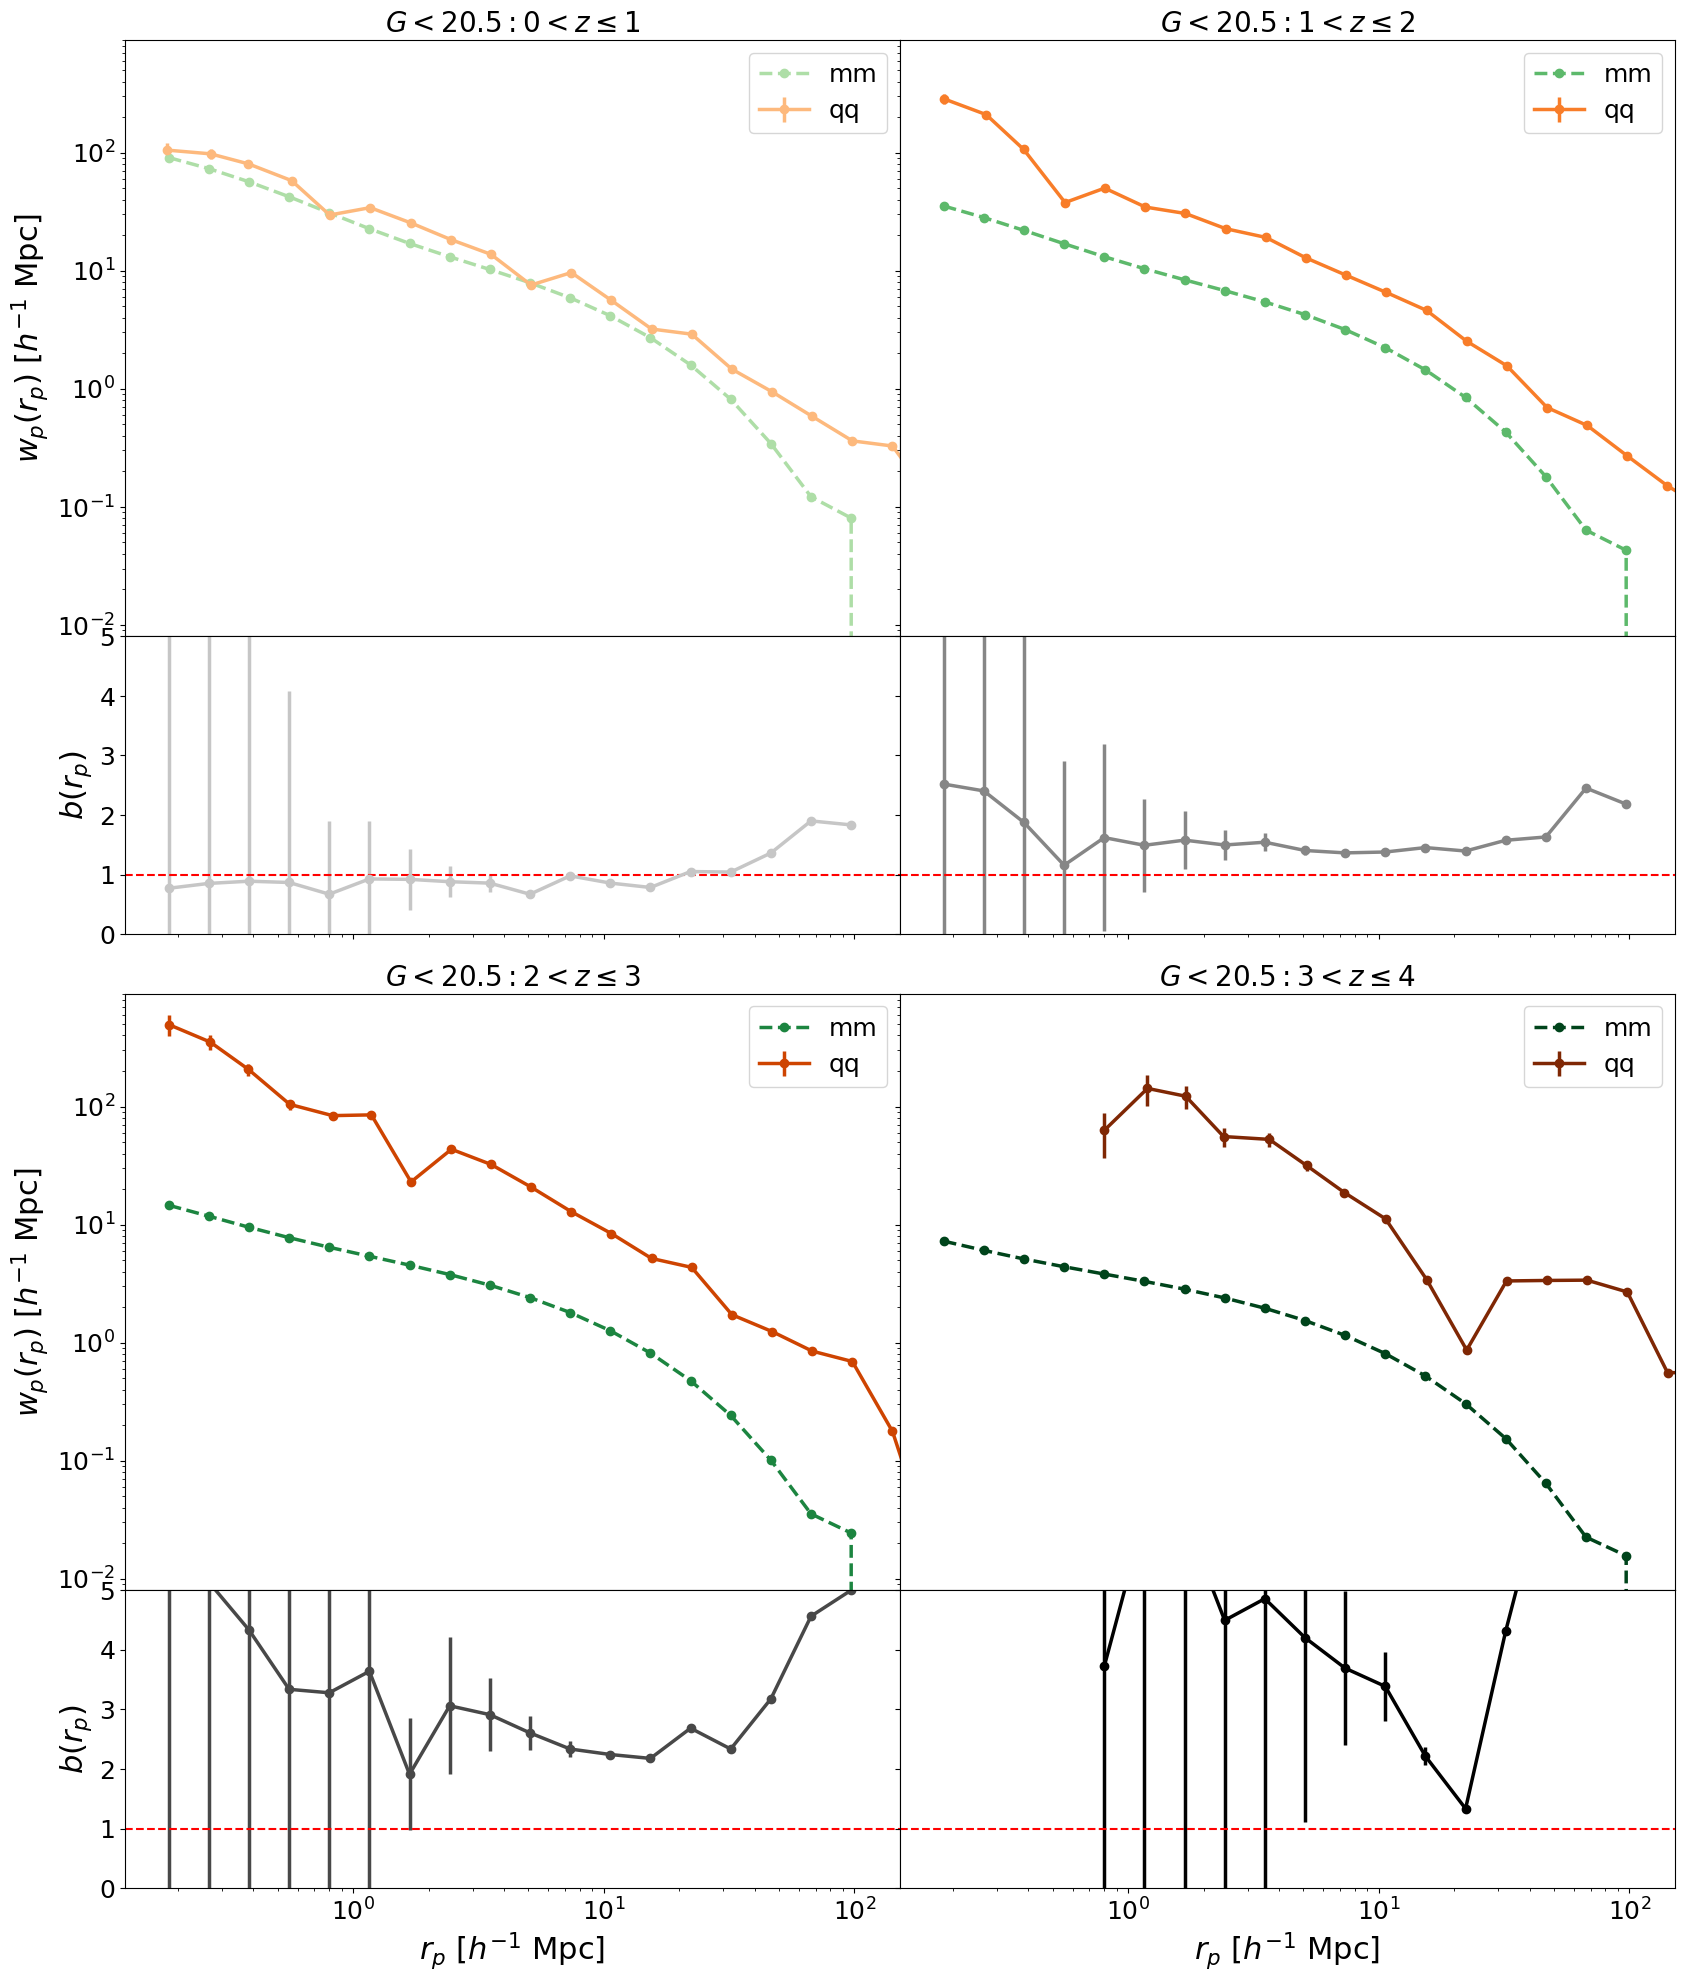

In [43]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
    
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j],
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    ax1.legend()
    
    # if j == 0:
    #     custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
    #                     Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
    #     second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    #     ax1.add_artist(second_legend)

    # patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    # first_legend = ax1.legend(handles=patch, loc = 'lower left')
    # ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/163535820.py:20: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/163535820.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3
/tmp/ipykernel_230519/2473749513.py:3: RuntimeWarning: invalid value encoun

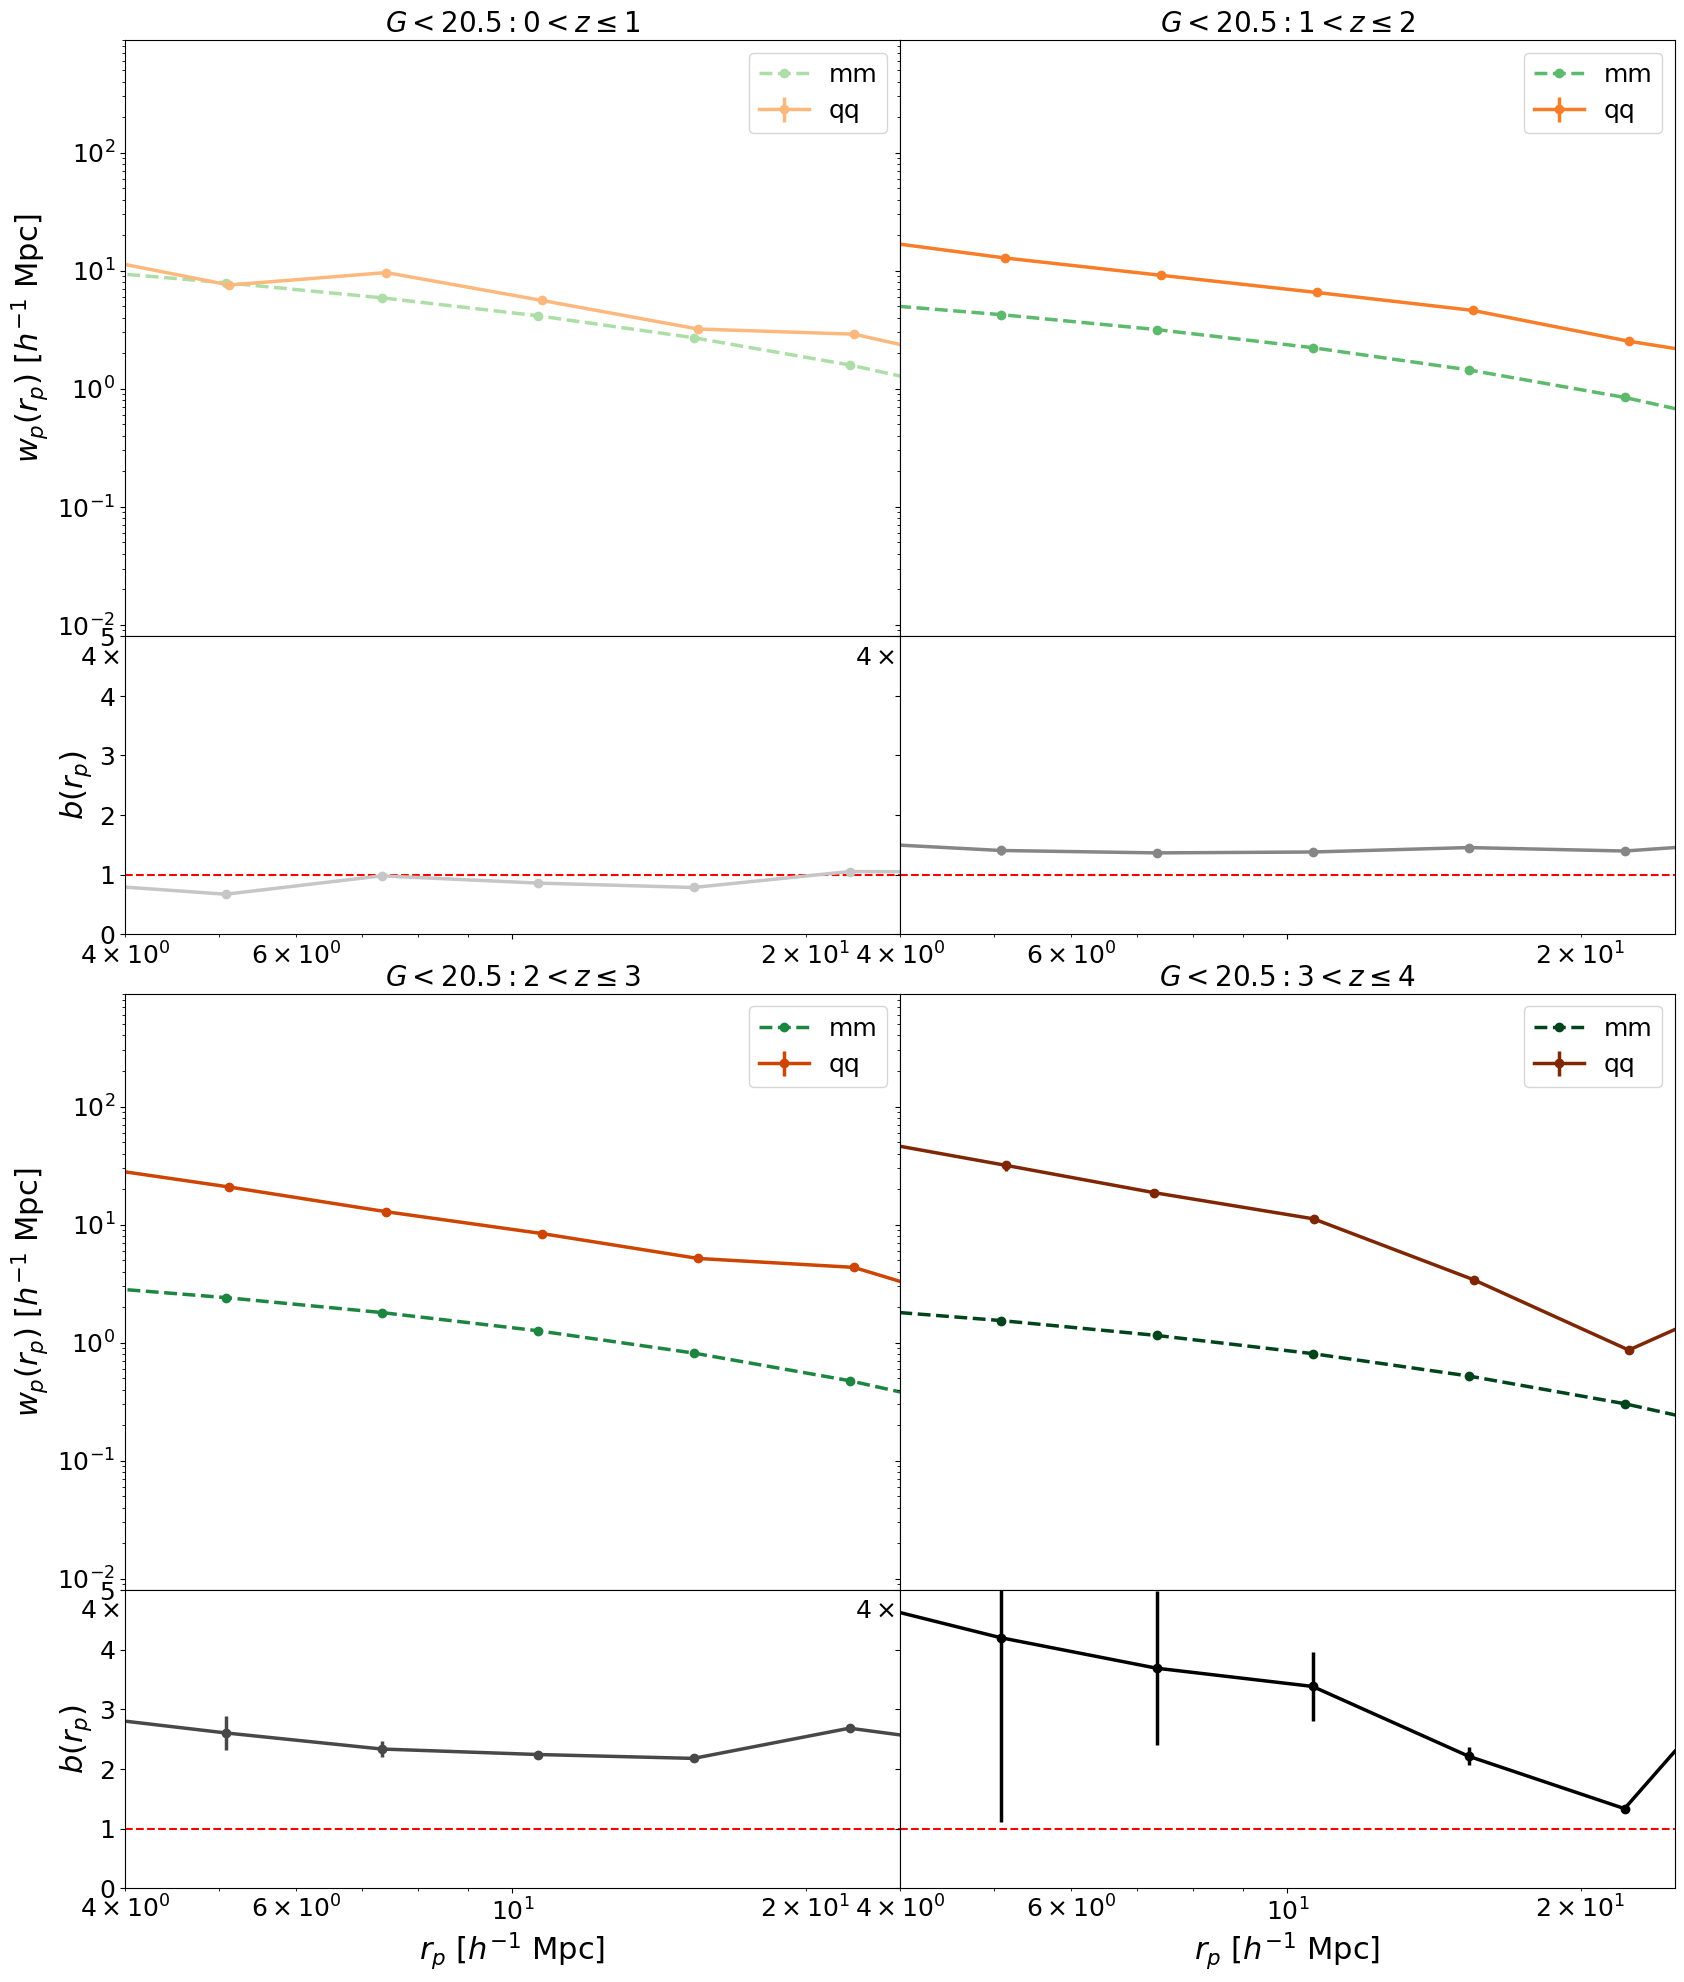

In [44]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    # for i in range(len(Omega_m_array)):
    
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', 
                 color = cmap_qq[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_b[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    ax1.legend()
    
    # if j == 0:
    #     custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
    #                     Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
    #     second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    #     ax1.add_artist(second_legend)

    # patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    # first_legend = ax1.legend(handles=patch, loc = 'lower left')
    # ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/3874555153.py:21: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/3874555153.py:31: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/3874555153.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
/tmp/ipykernel_230519/3874555153.py:20: RuntimeWarning: invalid value encountered in sqrt
  ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), line

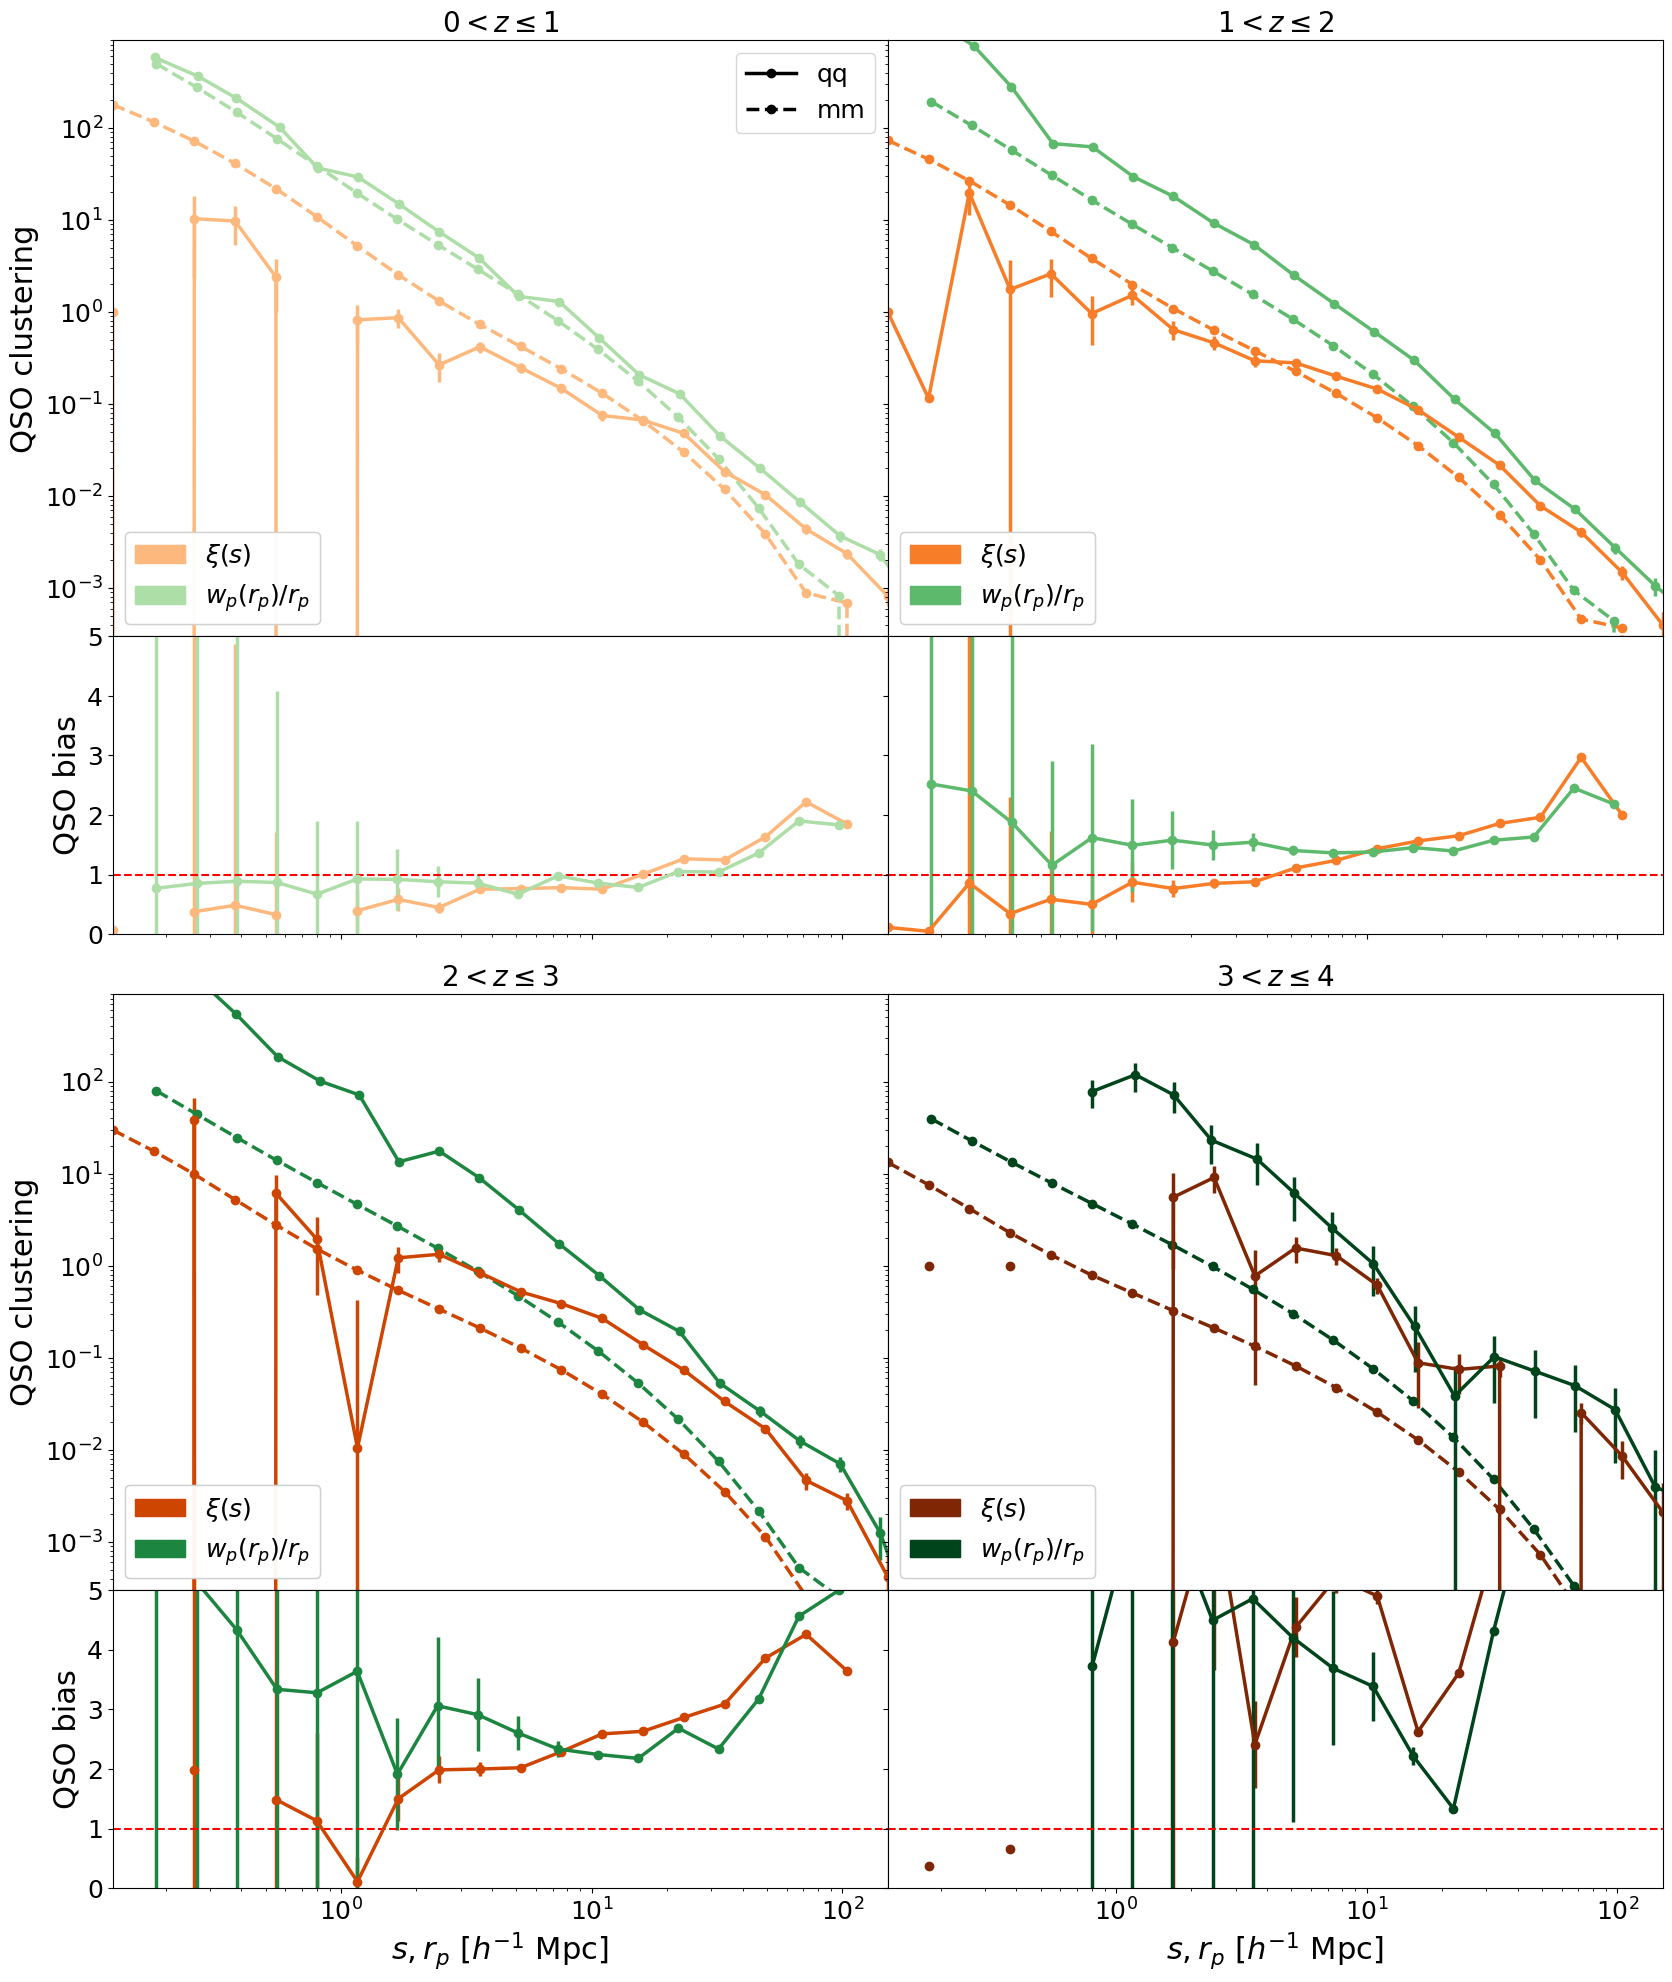

In [45]:
labels_cf = ['qq', 'mm']

# for i in range(len(Omega_m_array)):
    
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:
    
    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    #cf
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), linewidth = 2.5, 
                 marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    
    #wp
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j]/rpavg_zbin_percentile[j], linewidth = 2.5, 
                 marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
             color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', #title = '$G<{}$'.format(G_hi, labels[i]), title_fontsize = 18, 
                                   alignment = 'right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels_cf))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'QSO clustering')
        ax2.set_ylabel(r'QSO bias')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])

    if j % 2 != 0:
        k+=4

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/1465218031.py:21: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/1465218031.py:31: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/1465218031.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
/tmp/ipykernel_230519/1465218031.py:20: RuntimeWarning: invalid value encountered in sqrt
  ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), line

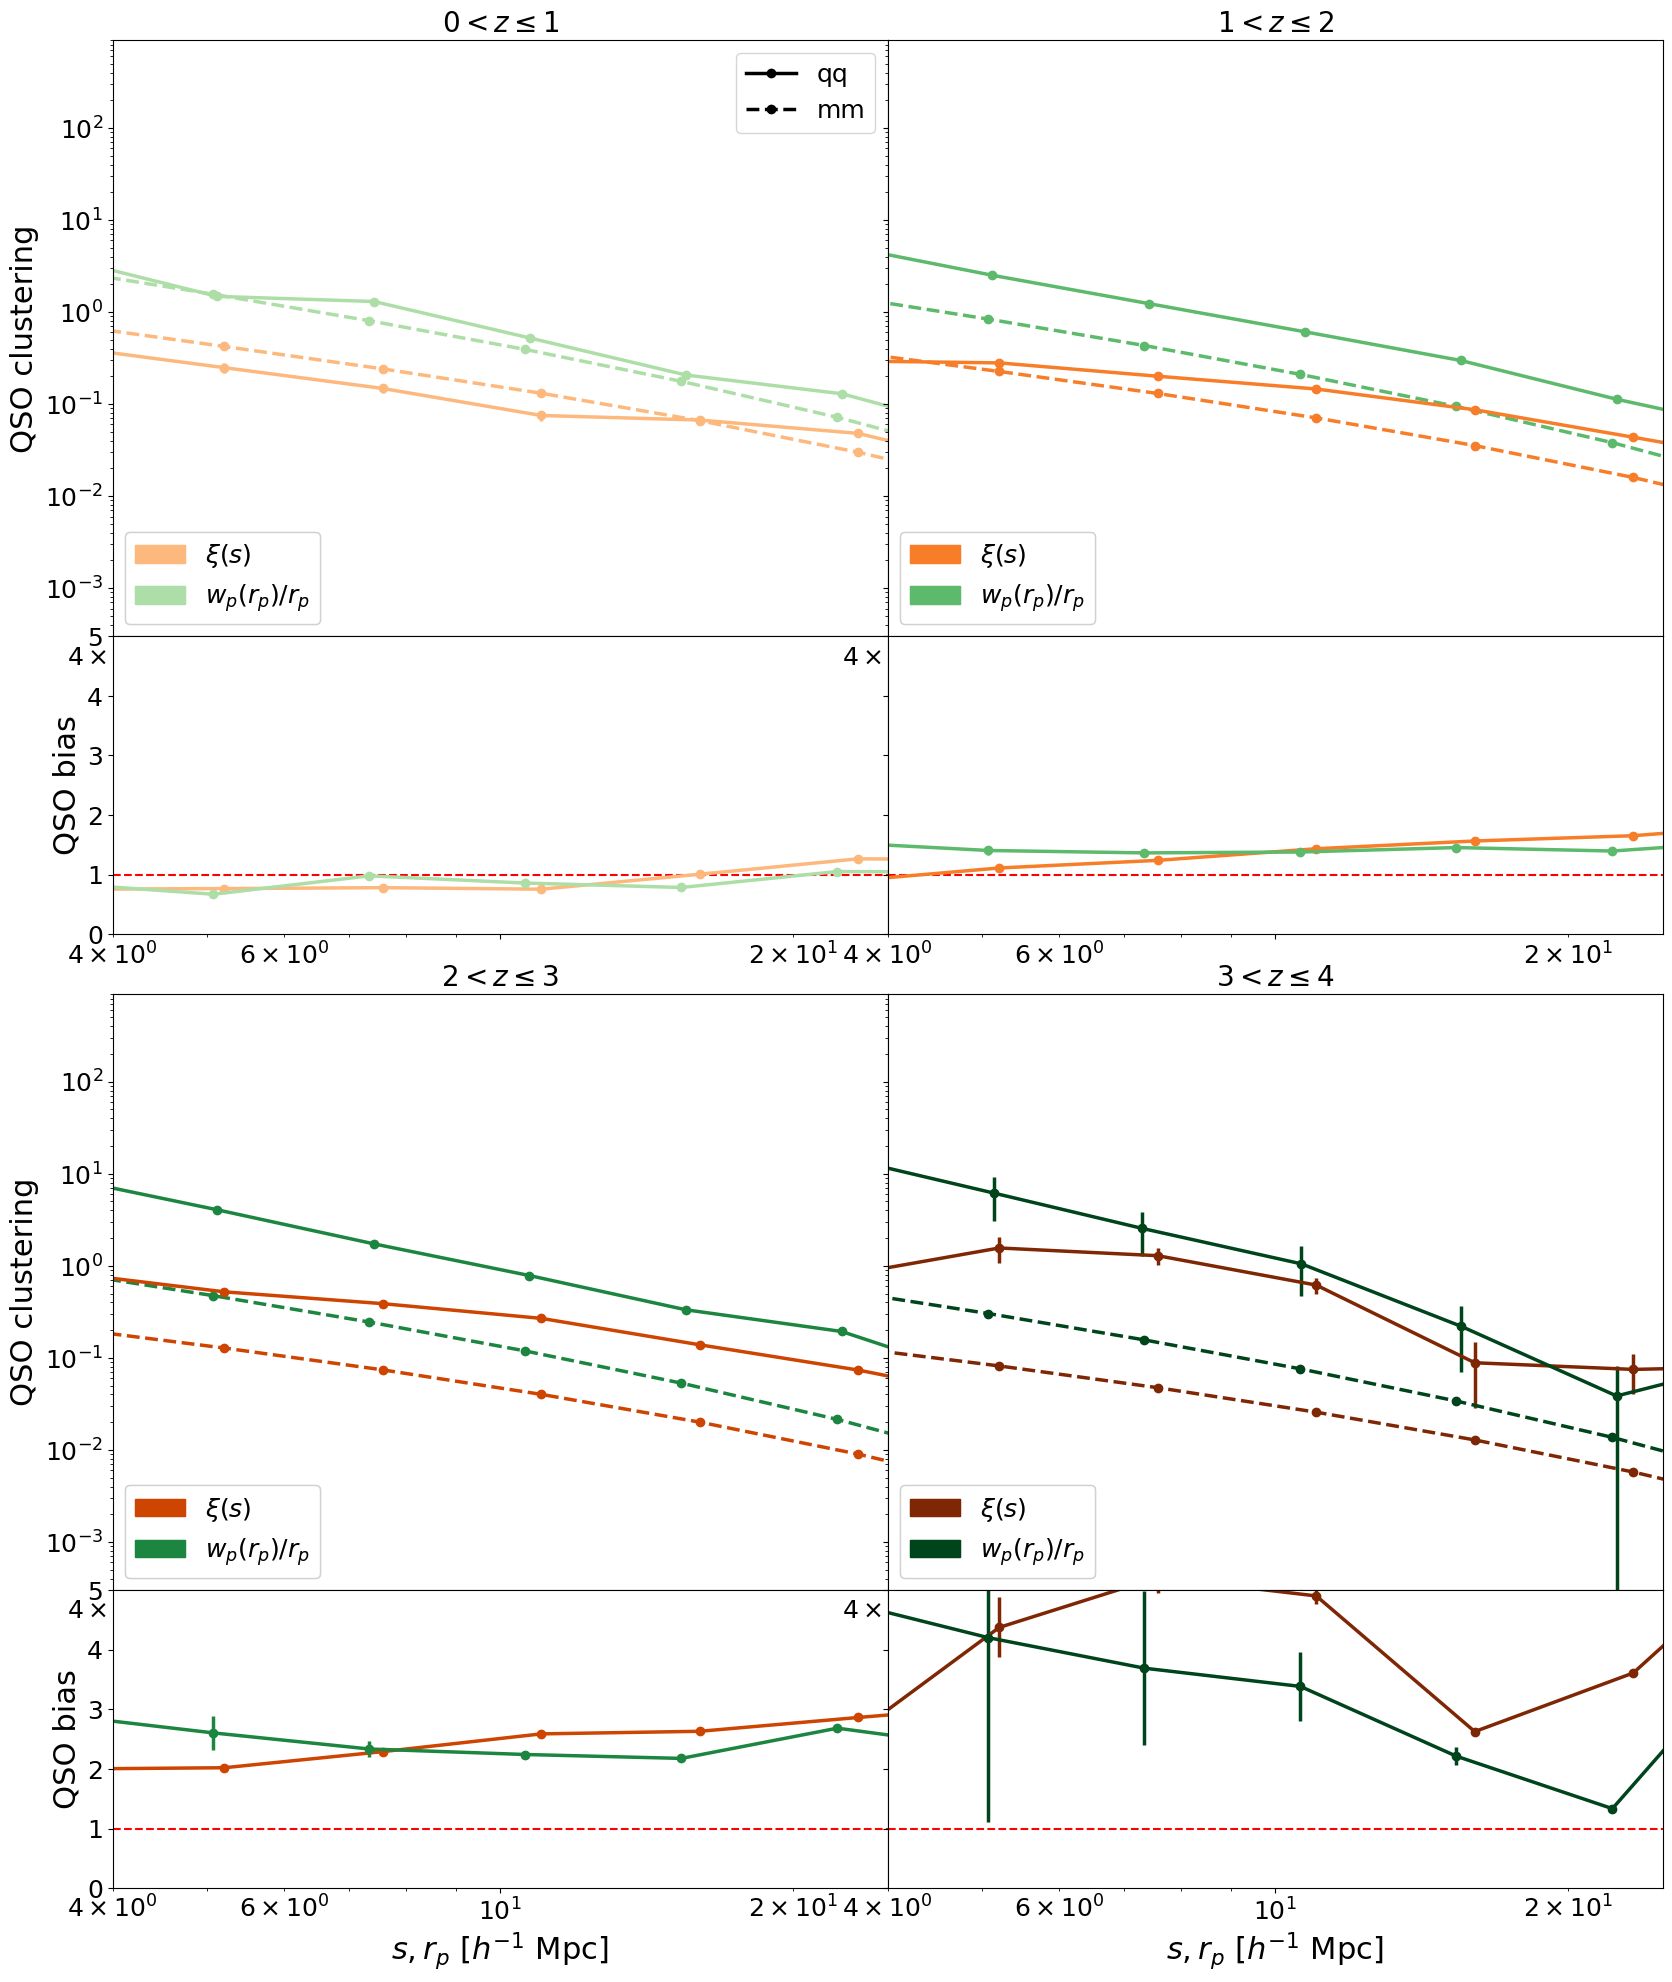

In [46]:
labels_cf = ['qq', 'mm']

# for i in range(len(Omega_m_array)):
    
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:
    
    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    #cf
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), linewidth = 2.5, 
                 marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    
    #wp
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j]/rpavg_zbin_percentile[j], linewidth = 2.5, 
                 marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
             color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', # title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                   title_fontsize = 18, alignment = 'right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels_cf))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'QSO clustering')
        ax2.set_ylabel(r'QSO bias')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])

    if j % 2 != 0:
        k+=4

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/1402473289.py:21: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/1402473289.py:31: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/1402473289.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
/tmp/ipykernel_230519/1402473289.py:20: RuntimeWarning: invalid value encountered in sqrt
  ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), line

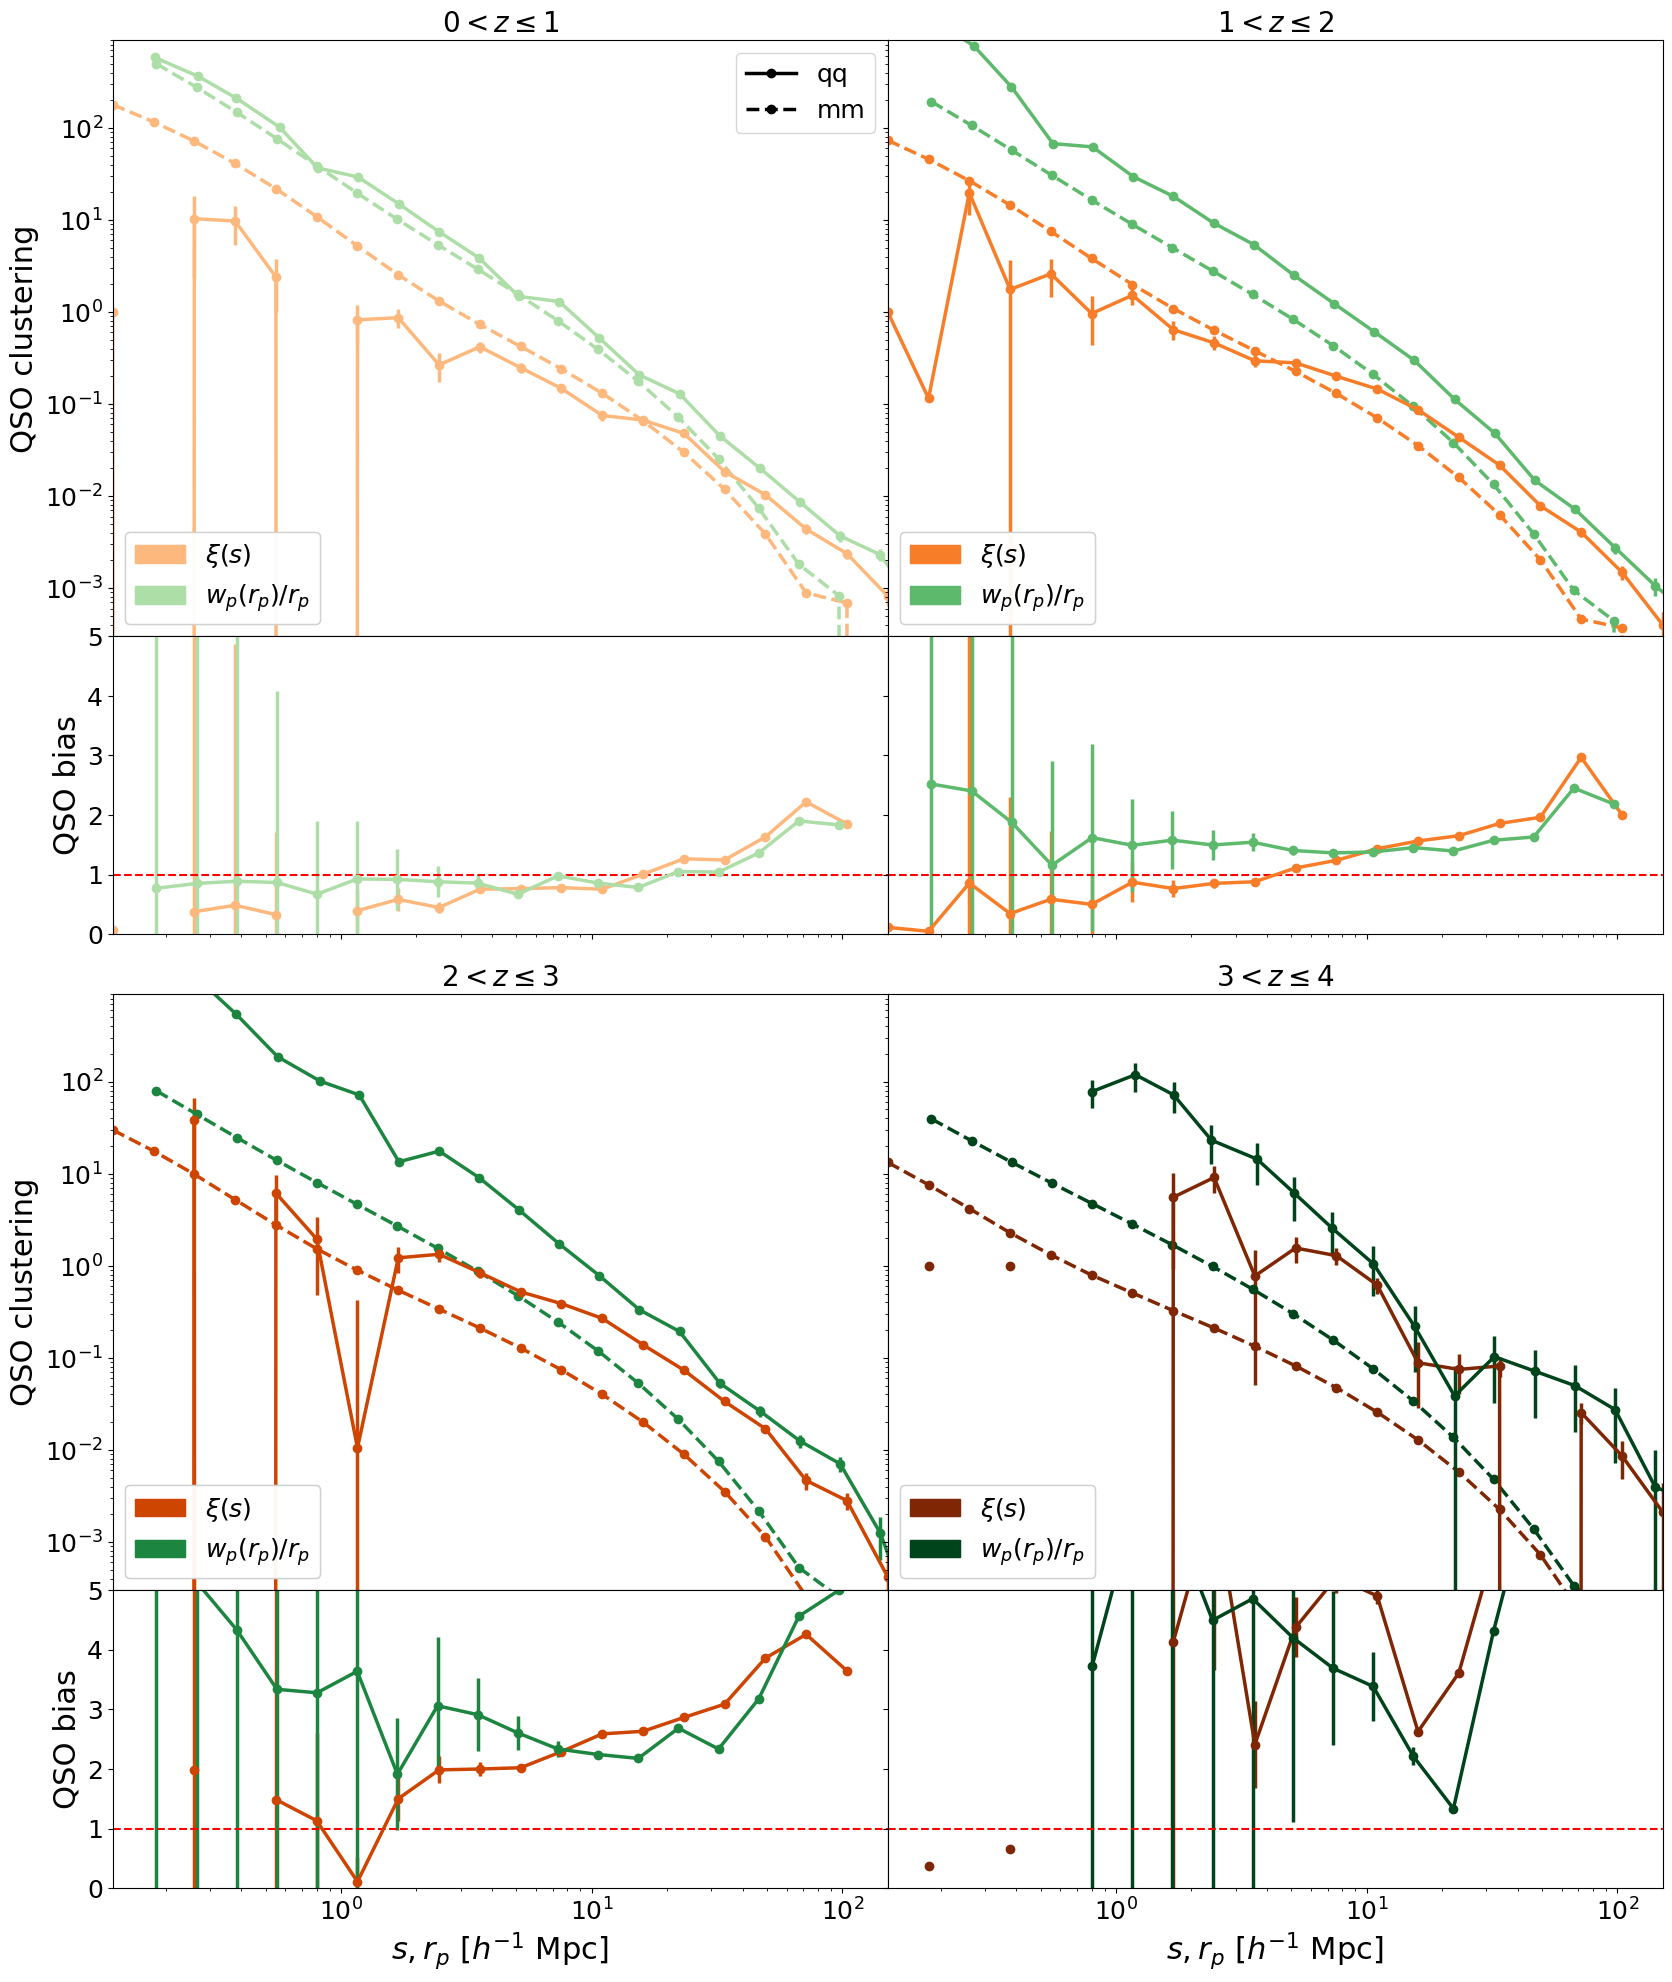

In [47]:
labels_cf = ['qq', 'mm']

# for i in range(len(Omega_m_array)):
    
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:
    
    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    #cf
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), linewidth = 2.5, 
                 marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    
    #wp
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j]/rpavg_zbin_percentile[j], linewidth = 2.5, 
                 marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
             color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j], 
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', # title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                   title_fontsize = 18, alignment = 'right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels_cf))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'QSO clustering')
        ax2.set_ylabel(r'QSO bias')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])

    if j % 2 != 0:
        k+=4

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_230519/2679089072.py:21: SyntaxWarning: invalid escape sequence '\l'
  marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_230519/2679089072.py:31: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])
/tmp/ipykernel_230519/2679089072.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
/tmp/ipykernel_230519/2679089072.py:20: RuntimeWarning: invalid value encountered in sqrt
  ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), line

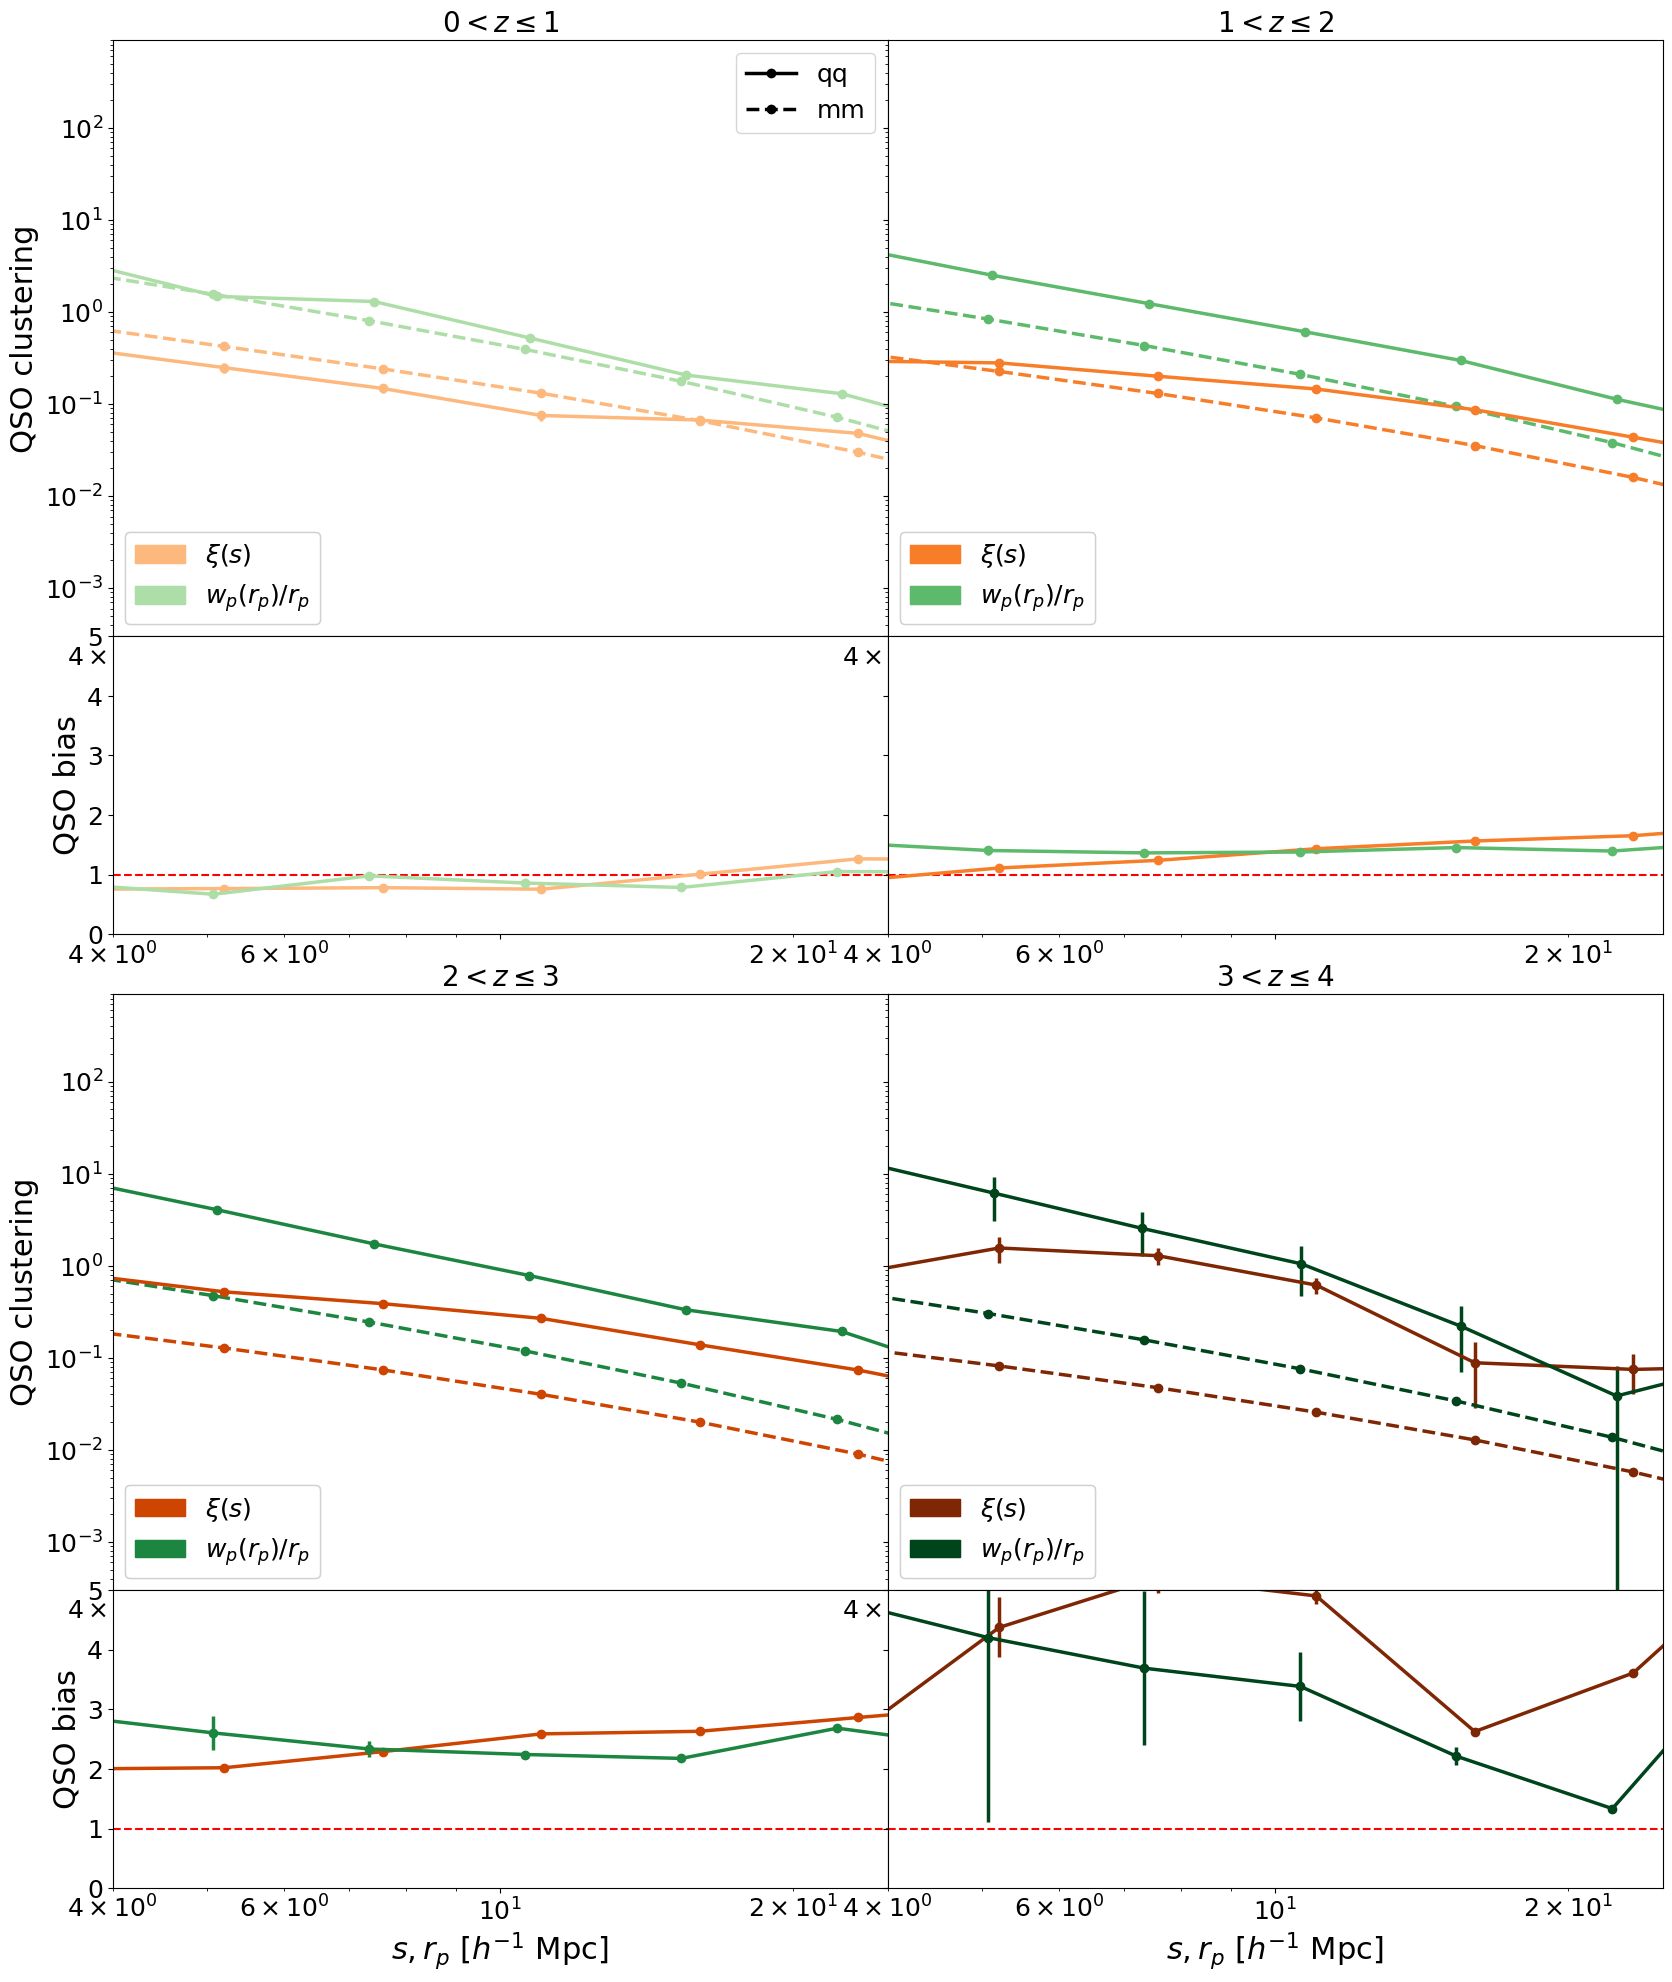

In [48]:
labels_cf = ['qq', 'mm']

# for i in range(len(Omega_m_array)):
    
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:
    
    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    #cf
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                 yerr = yerr_cf[j])
    ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
             linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[j]/cf_matter_zbin_percentile[j]), linewidth = 2.5, 
                 marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    
    #wp
    ax1.errorbar(rpavg_zbin_percentile[j], wp_zbin_percentile[j]/rpavg_zbin_percentile[j], linewidth = 2.5, 
                 marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[j])
    ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
             color = cmap_mm[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[j], wp_matter_zbin_percentile[j],
                                              ccl.growth_rate(cosmo_planck18, a_zbin[j])), linewidth = 2.5, marker = 'o', 
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[j])

    if (j + k) % 6 < 2:
        ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', # title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                   title_fontsize = 18, alignment = 'right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels_cf))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'QSO clustering')
        ax2.set_ylabel(r'QSO bias')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])

    if j % 2 != 0:
        k+=4

plt.show()

## Plot effective bias evolution at a fixed scale
### $\xi(z)$

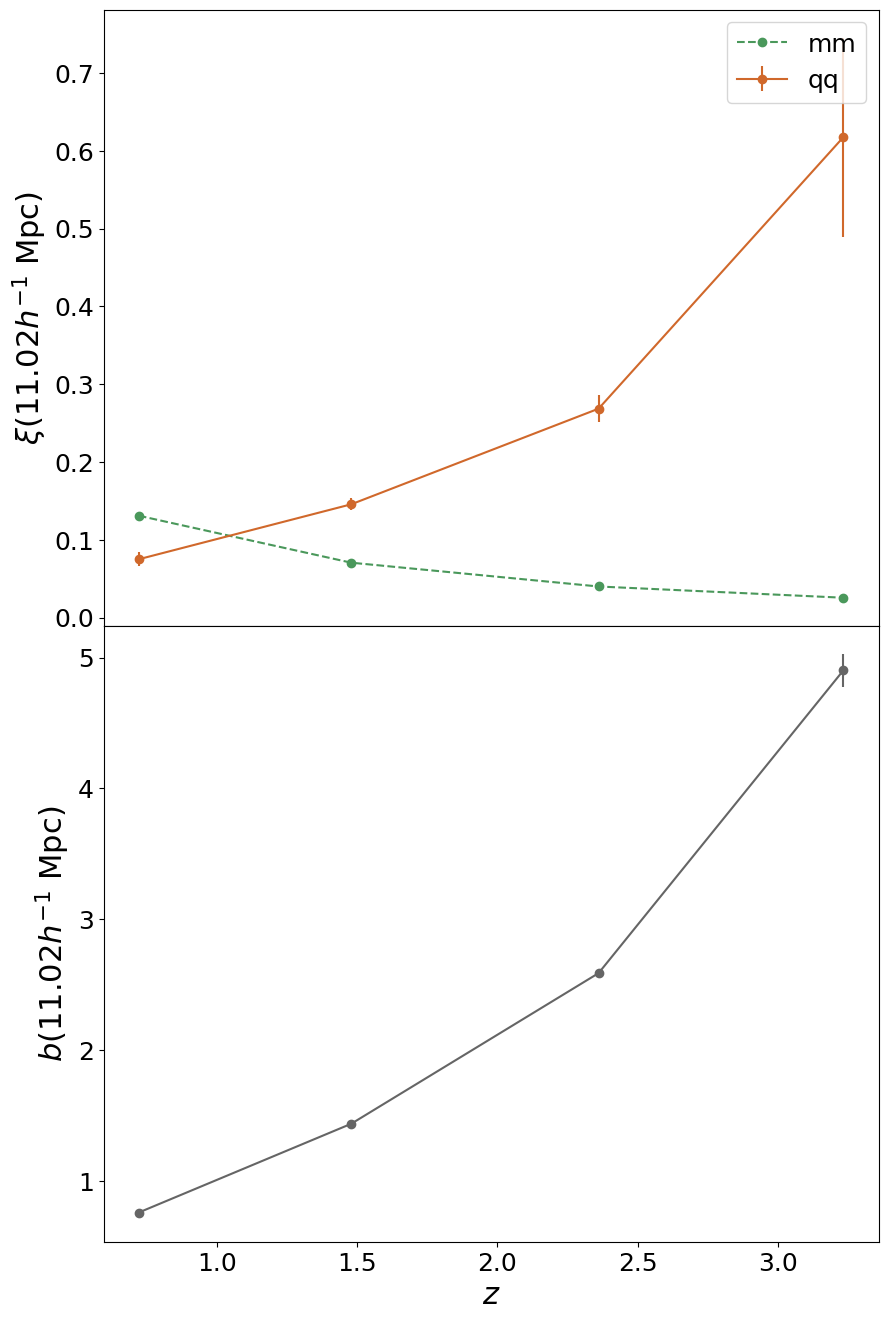

In [49]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

# for i in range(len(labels)):
    
cf_zbin_percentile_k = np.array([cf_zbin_percentile[j][k] for j in z_array])
cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_cf[j][k] for j in z_array]

# for j in z_array:

ax1.errorbar(1/np.array(a_zbin)-1, cf_zbin_percentile_k, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0), 
             yerr = yerr_k)
ax1.plot(1/np.array(a_zbin)-1, cf_matter_zbin_percentile_k, marker = 'o', color = np.mean(cmap_mm, axis = 0), label= 'mm',
         linestyle = '--')

ax2.errorbar(1/np.array(a_zbin)-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', 
             color = np.mean(cmap_b, axis = 0), yerr = yerr_k)
ax1.legend()
    
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels_cf[l]) for l in range(len(labels_cf))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

### $w_p(s)$

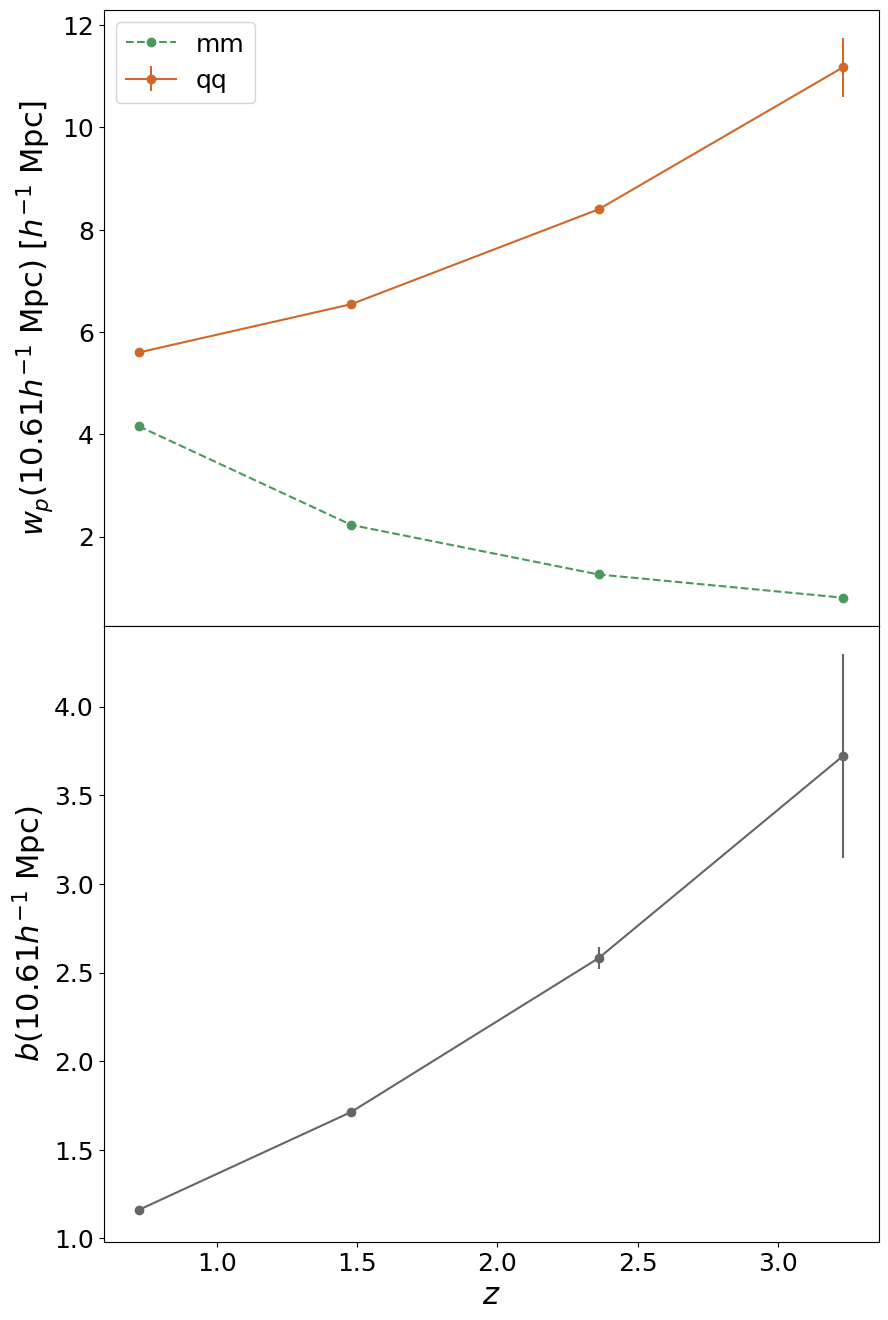

In [50]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rpbins)-10))

# for i in range(len(labels)):
    
wp_zbin_percentile_k = np.array([wp_zbin_percentile[j][k] for j in z_array])
wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_wp[j][k] for j in z_array]

ax1.errorbar(1/np.array(a_zbin)-1, wp_zbin_percentile_k, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0), 
             yerr = yerr_k)
ax1.plot(1/np.array(a_zbin)-1, wp_matter_zbin_percentile_k, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), 
         linestyle = '--')

ax2.errorbar(1/np.array(a_zbin)-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', #label = labels[i], 
         color = np.mean(cmap_b, axis = 0), yerr = yerr_k)
ax1.legend()
    
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_p({:.2f} h^{{-1}}$ Mpc) $[h^{{-1}}$ Mpc]'.format(quaia.recenter(rpbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rpbins)[k]))

plt.show()

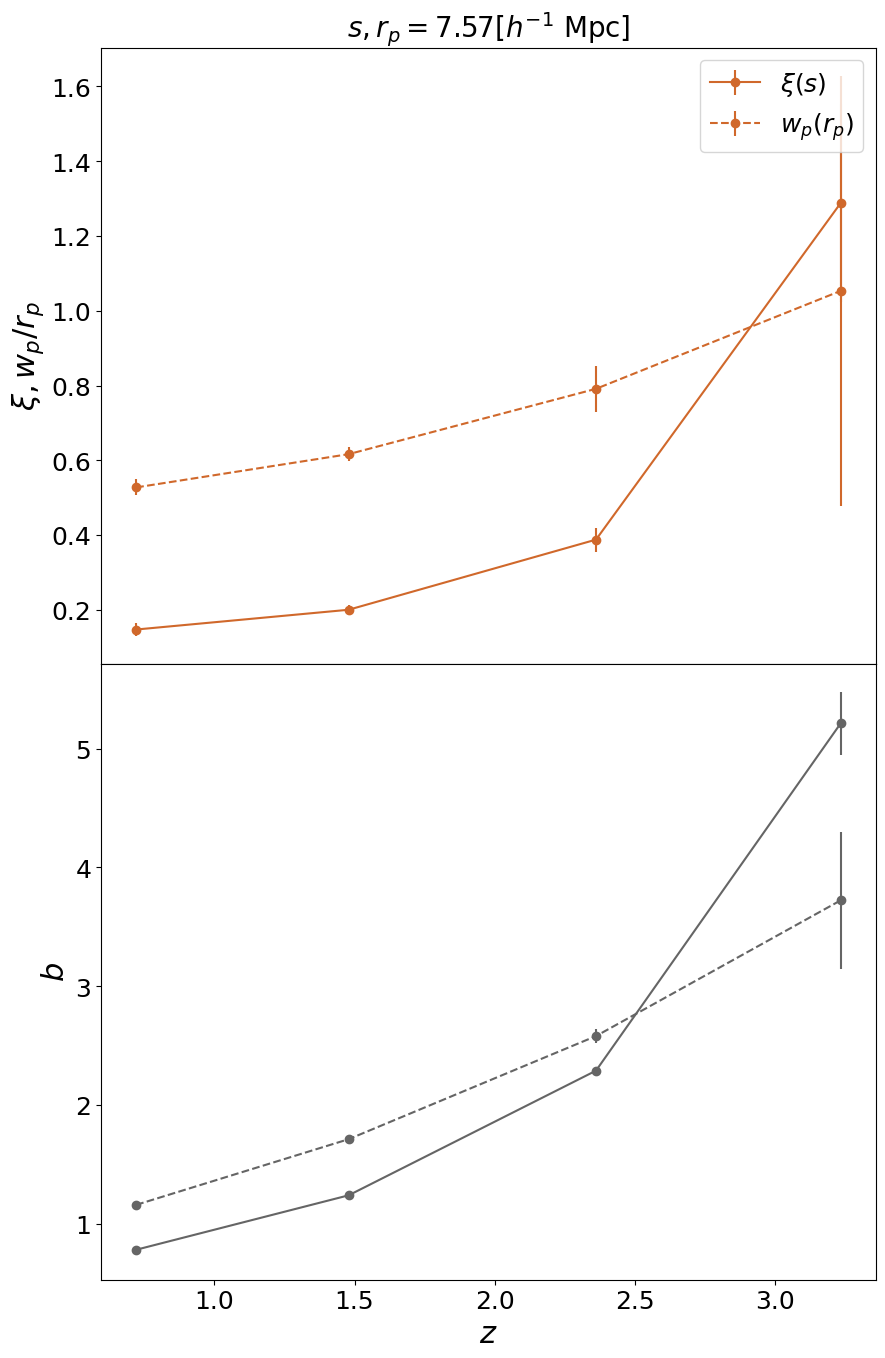

In [51]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
# cf
cf_zbin_percentile_k = np.array([cf_zbin_percentile[j][k] for j in z_array])
cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_cf[j][k] for j in z_array]

ax1.errorbar(1/np.array(a_zbin)-1, cf_zbin_percentile_k, marker = 'o', label = r'$\xi(s)$', color = np.mean(cmap_qq, axis = 0), 
             yerr = yerr_k)
ax2.errorbar(1/np.array(a_zbin)-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', 
             color = np.mean(cmap_b, axis = 0), yerr = yerr_k)

# wp
wp_zbin_percentile_k = np.array([wp_zbin_percentile[j][k] for j in z_array])
wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_wp[j][k] for j in z_array]

ax1.errorbar(1/np.array(a_zbin)-1, wp_zbin_percentile_k/quaia.recenter(rpbins)[k], marker = 'o', label = '$w_p(r_p)$',
             color = np.mean(cmap_qq, axis = 0), linestyle = '--', yerr = yerr_k)
ax2.errorbar(1/np.array(a_zbin)-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', #label = labels[i], 
             color = np.mean(cmap_b, axis = 0), linestyle = '--', yerr = yerr_k)
ax1.legend()
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)/r_p$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
ax1.set_title('$s,r_p = {:.2f}[h^{{-1}}$ Mpc]'.format(quaia.recenter(rbins)[k]))

# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi, w_p/r_p$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b$')

plt.show()

## Plot quasar bias evolution at a fixed scale
### $\xi(s)$

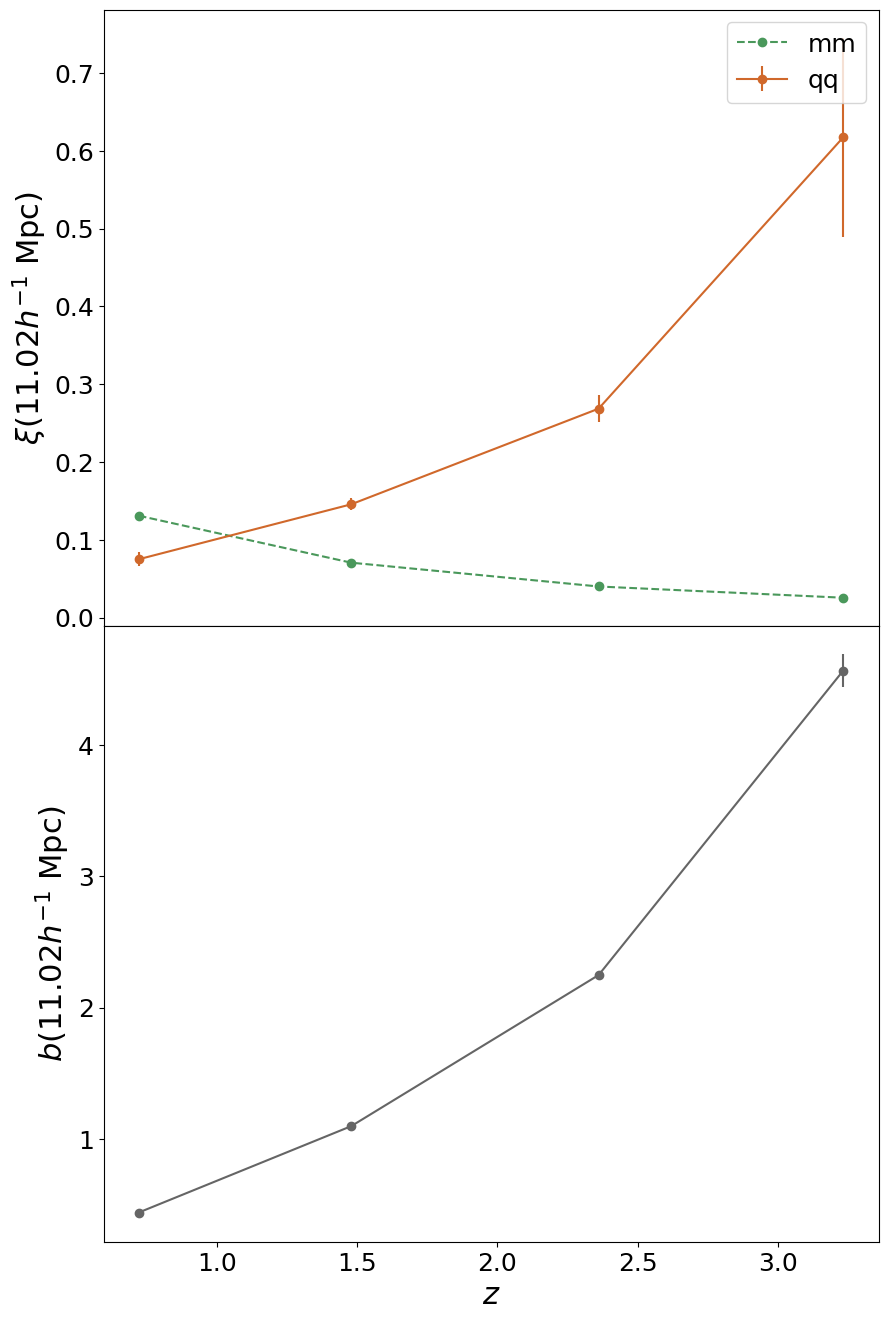

In [52]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

# for i in range(len(labels)):
    
cf_zbin_percentile_k = np.array([cf_zbin_percentile[j][k] for j in z_array])
cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_cf[j][k] for j in z_array]

ax1.errorbar(1/np.array(a_zbin)-1, cf_zbin_percentile_k, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0), 
             yerr = yerr_k)
ax1.plot(1/np.array(a_zbin)-1, cf_matter_zbin_percentile_k, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), 
         linestyle = '--')

ax2.errorbar(1/np.array(a_zbin)-1, bias(cf_zbin_percentile_k, cf_matter_zbin_percentile_k,
                                              ccl.growth_rate(cosmo_planck18, a_zbin)), marker = 'o', #label = labels[i], 
             color = np.mean(cmap_b, axis = 0), yerr = yerr_k)

ax1.legend()
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

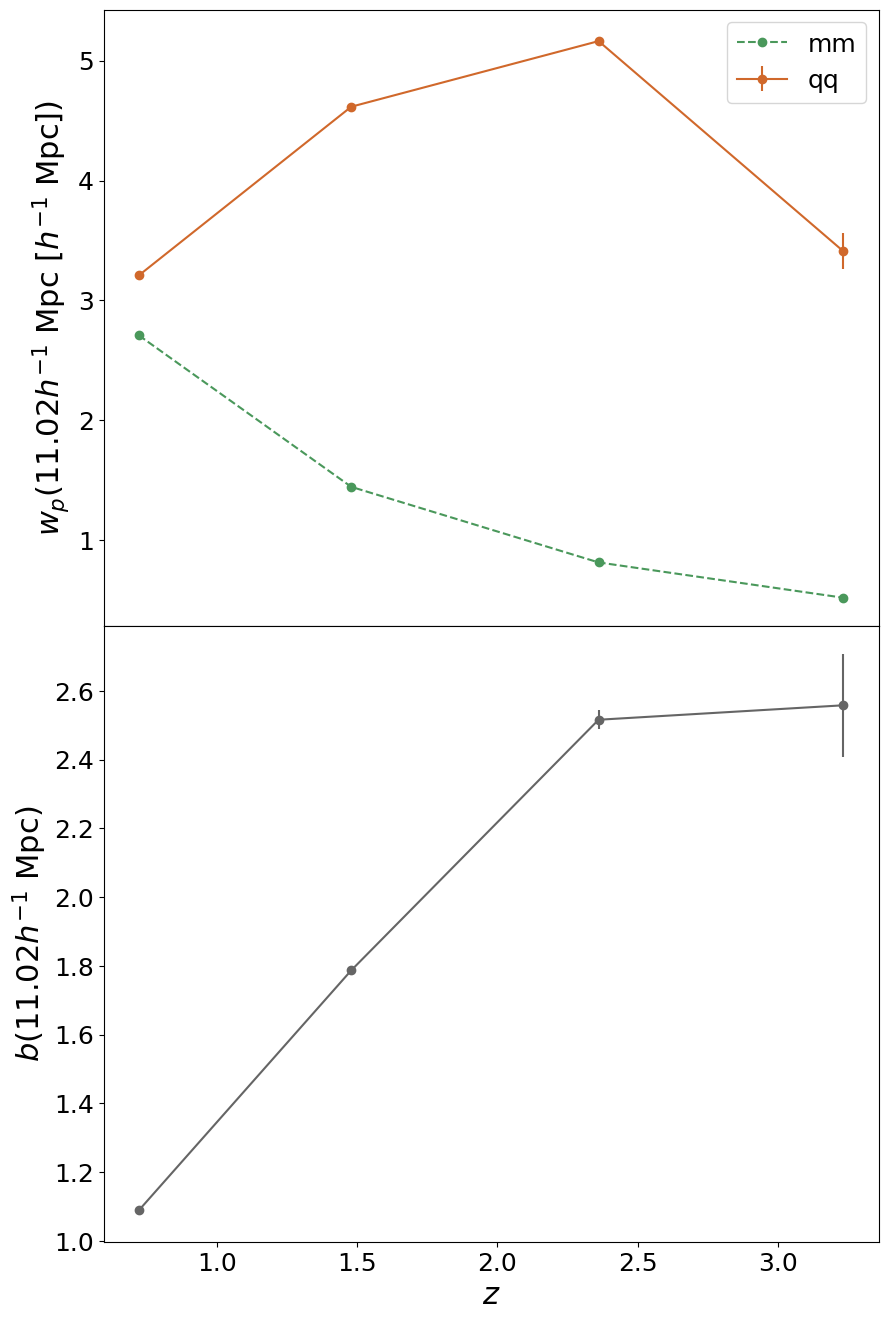

In [53]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

# for i in range(len(labels)):
    
wp_zbin_percentile_k = np.array([wp_zbin_percentile[j][k] for j in z_array])
wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[j][k] for j in z_array]
yerr_k = [yerr_wp[j][k] for j in z_array]

ax1.errorbar(1/np.array(a_zbin)-1, wp_zbin_percentile_k, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0), 
             yerr = yerr_k)
ax1.plot(1/np.array(a_zbin)-1, wp_matter_zbin_percentile_k, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), 
         linestyle = '--')

ax2.errorbar(1/np.array(a_zbin)-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', #label = labels[i], 
             color = np.mean(cmap_b, axis = 0), yerr = yerr_k)
ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_p({:.2f} h^{{-1}}$ Mpc $[h^{{-1}}$ Mpc])'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

# Try the integration method
## Compute $\xi_{20}=3 / 20^3 \int_0^{20} \xi(s) s^2 d s$

In [54]:
labels_cf = ['qq', 'mm']
cf_20=[]
cf_matter_20=[]
# for i in range(len(Omega_m_array)):

for j in z_array:

    # quasars
    bounds = quaia.recenter(rbins)<20
    integrand = np.copy(cf_zbin_percentile[j])*quaia.recenter(rbins)**2
    integrand[np.isnan(integrand)]=0
    cf_20.append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))
    
    # matter
    integrand = np.copy(cf_matter_zbin_percentile[j])*quaia.recenter(rbins)**2
    integrand[np.isnan(integrand)]=0
    cf_matter_20.append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))

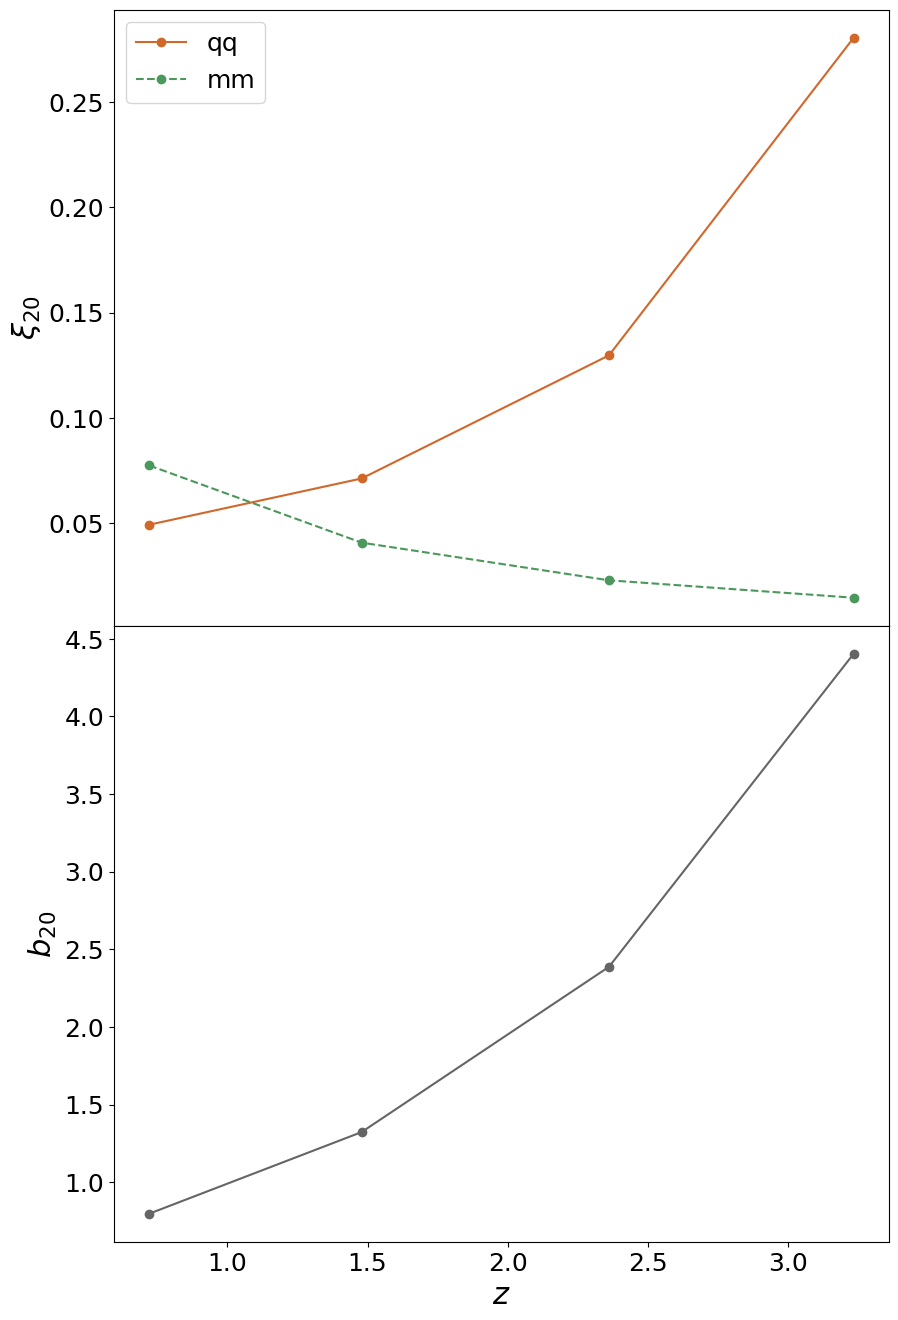

In [55]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
ax1.plot(1/np.array(a_zbin)-1, cf_20, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0))
ax1.plot(1/np.array(a_zbin)-1, cf_matter_20, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), linestyle = '--')

ax2.plot(1/np.array(a_zbin)-1, np.sqrt(np.array(cf_20)/cf_matter_20), marker = 'o', color = np.mean(cmap_b, axis = 0))
    
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Compute $w_{p,20}=2 / 20^2 \int_0^{20} w_p(r_p) r_p d r_p$

In [56]:
labels_cf = ['qq', 'mm']
wp_20=[]
wp_matter_20=[]
# for i in range(len(Omega_m_array)):

for j in z_array:

    # quasars
    bounds = np.array(rpavg_zbin_percentile[j])<20
    integrand = np.copy(wp_zbin_percentile[j])*rpavg_zbin_percentile[j]
    integrand[np.isnan(integrand)]=0
    wp_20.append(3/(20**3)*np.trapz(integrand[bounds], np.array(rpavg_zbin_percentile[j])[bounds]))
    
    # matter
    integrand = np.copy(wp_matter_zbin_percentile[j])*quaia.recenter(rpbins)
    integrand[np.isnan(integrand)]=0
    wp_matter_20.append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rpbins)[bounds]))

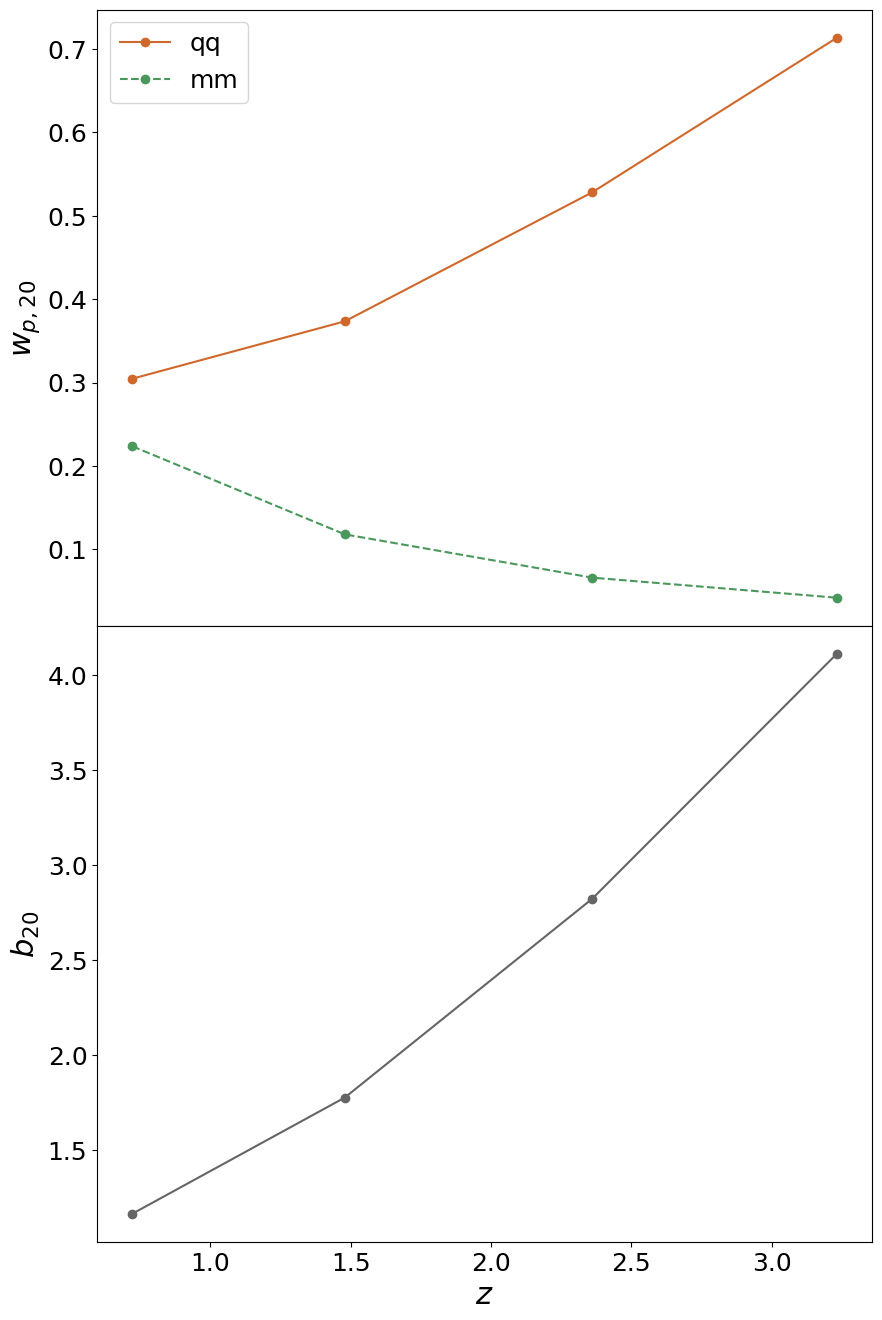

In [57]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
ax1.plot(1/np.array(a_zbin)-1, wp_20, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0))
ax1.plot(1/np.array(a_zbin)-1, wp_matter_20, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), linestyle = '--')

ax2.plot(1/np.array(a_zbin)-1, np.sqrt(np.array(wp_20)/wp_matter_20), marker = 'o', color = np.mean(cmap_b, axis = 0))
    
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

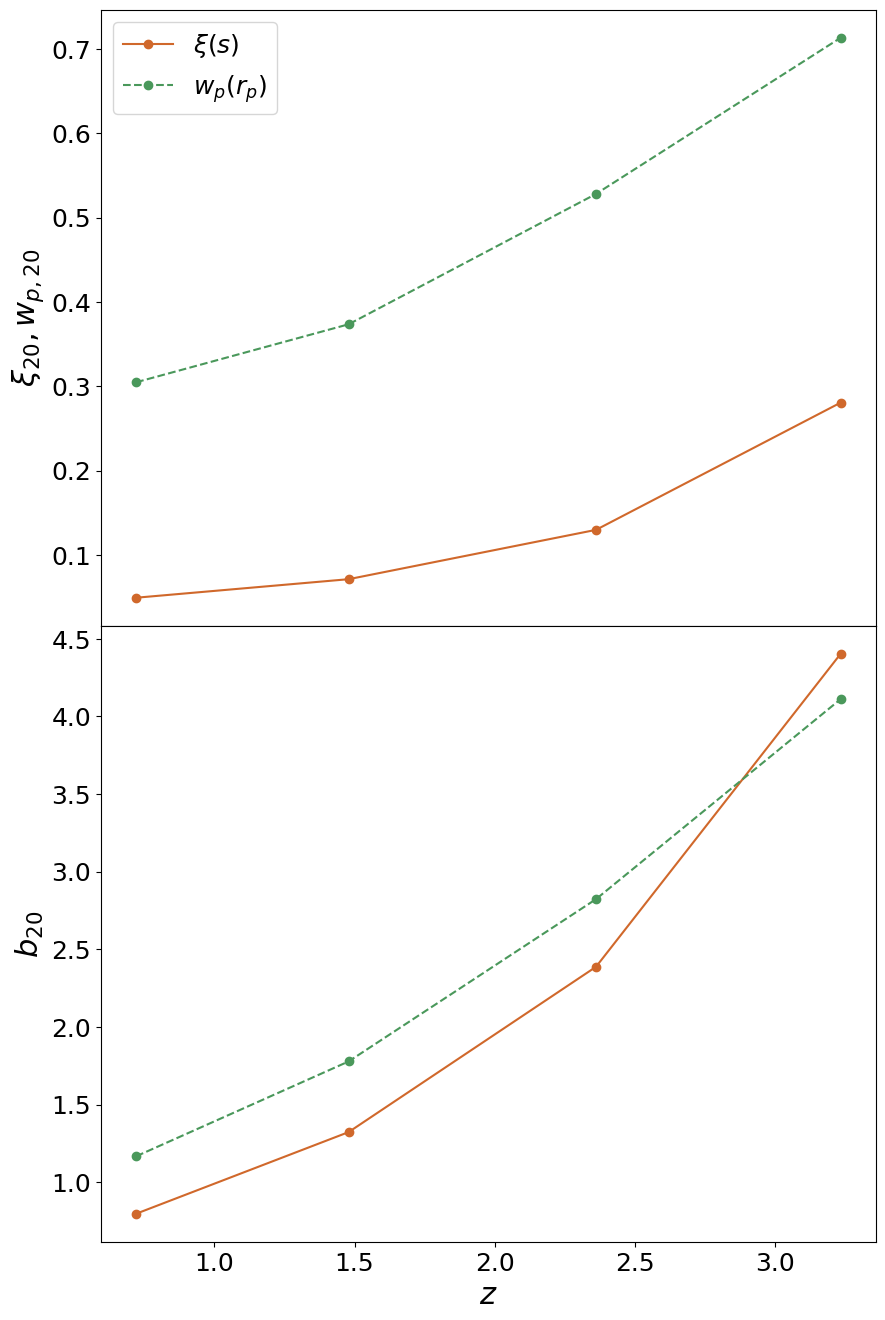

In [60]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
# cf
ax1.plot(1/np.array(a_zbin)-1, cf_20, marker = 'o', label = r'$\xi(s)$', color = np.mean(cmap_qq, axis = 0))
ax2.plot(1/np.array(a_zbin)-1, np.sqrt(np.array(cf_20)/cf_matter_20), marker = 'o', color = np.mean(cmap_qq, axis = 0))

# wp
ax1.plot(1/np.array(a_zbin)-1, wp_20, marker = 'o', label = '$w_p(r_p)$', color = np.mean(cmap_mm, axis = 0), linestyle = '--')
ax2.plot(1/np.array(a_zbin)-1, np.sqrt(np.array(wp_20)/wp_matter_20), marker = 'o', color = np.mean(cmap_mm, axis = 0), 
         linestyle = '--')
ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18,
#                            alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{20,qq}}}{\xi^{(r)}_\mathrm{20,mm}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

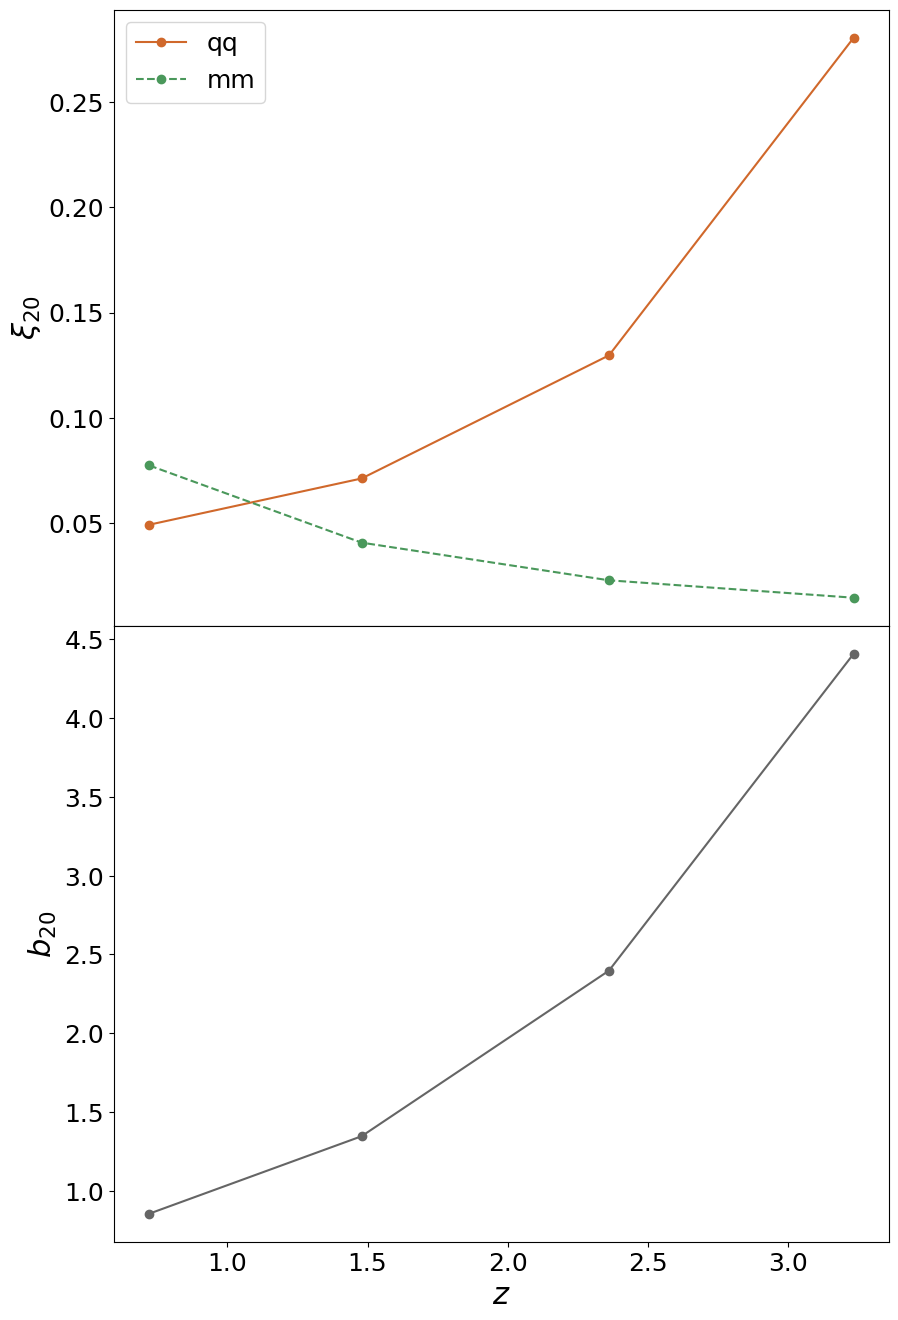

In [61]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
ax1.plot(1/np.array(a_zbin)-1, cf_20, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0))
ax1.plot(1/np.array(a_zbin)-1, cf_matter_20, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), linestyle = '--')

ax2.plot(1/np.array(a_zbin)-1, bias(np.array(cf_20), cf_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1), marker = 'o', 
         color = np.mean(cmap_b, axis = 0))
ax1.legend()
    
# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{w^{(s)}_{p,20,{\mathrm{qq}}}}{w^{(r)}_{p,20\mathrm{mm}}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

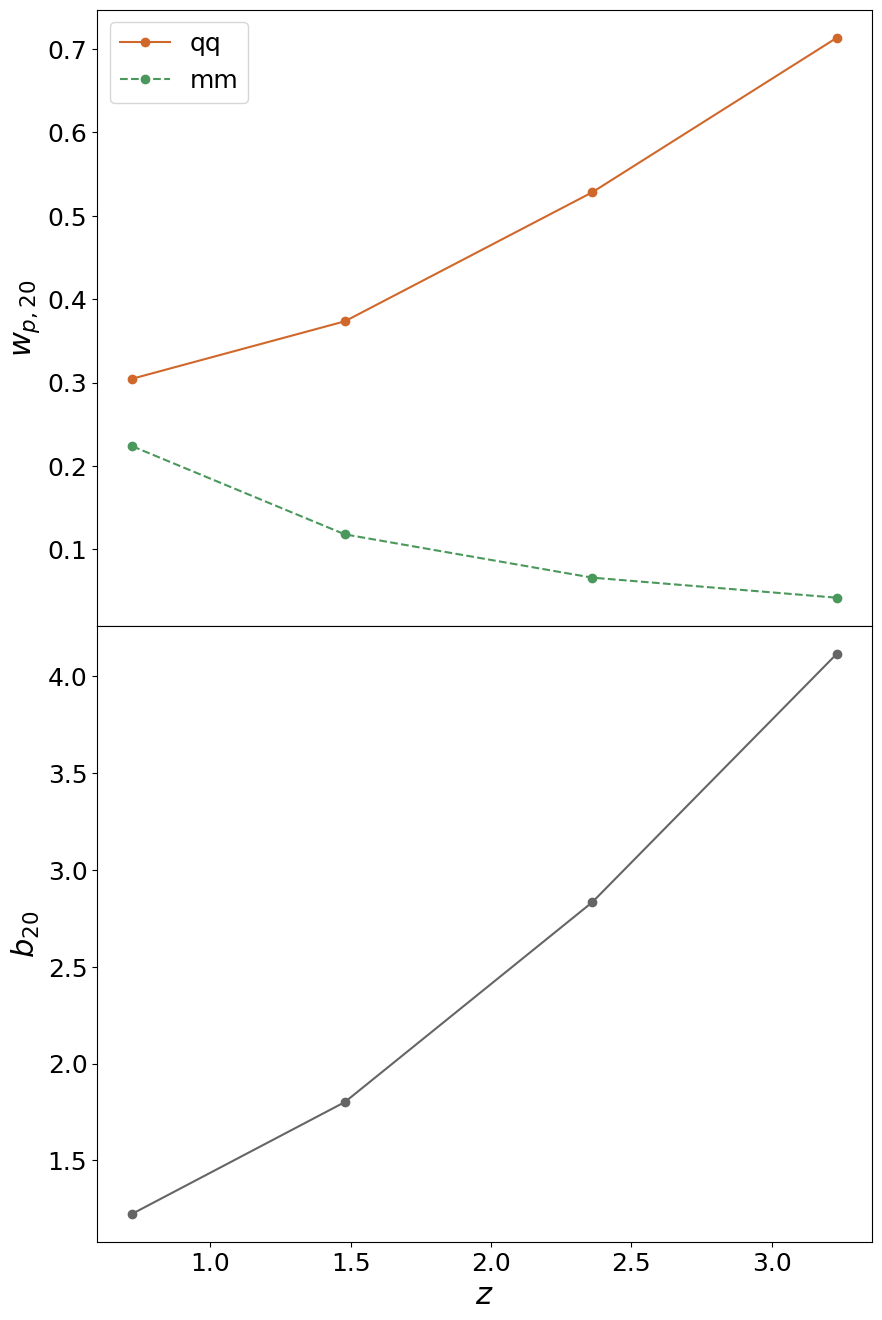

In [62]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
ax1.plot(1/np.array(a_zbin)-1, wp_20, marker = 'o', label = 'qq', color = np.mean(cmap_qq, axis = 0))
ax1.plot(1/np.array(a_zbin)-1, wp_matter_20, marker = 'o', label = 'mm', color = np.mean(cmap_mm, axis = 0), linestyle = '--')

ax2.plot(1/np.array(a_zbin)-1, bias(np.array(wp_20), wp_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1), marker = 'o', 
         color = np.mean(cmap_b, axis = 0))
ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')
# ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

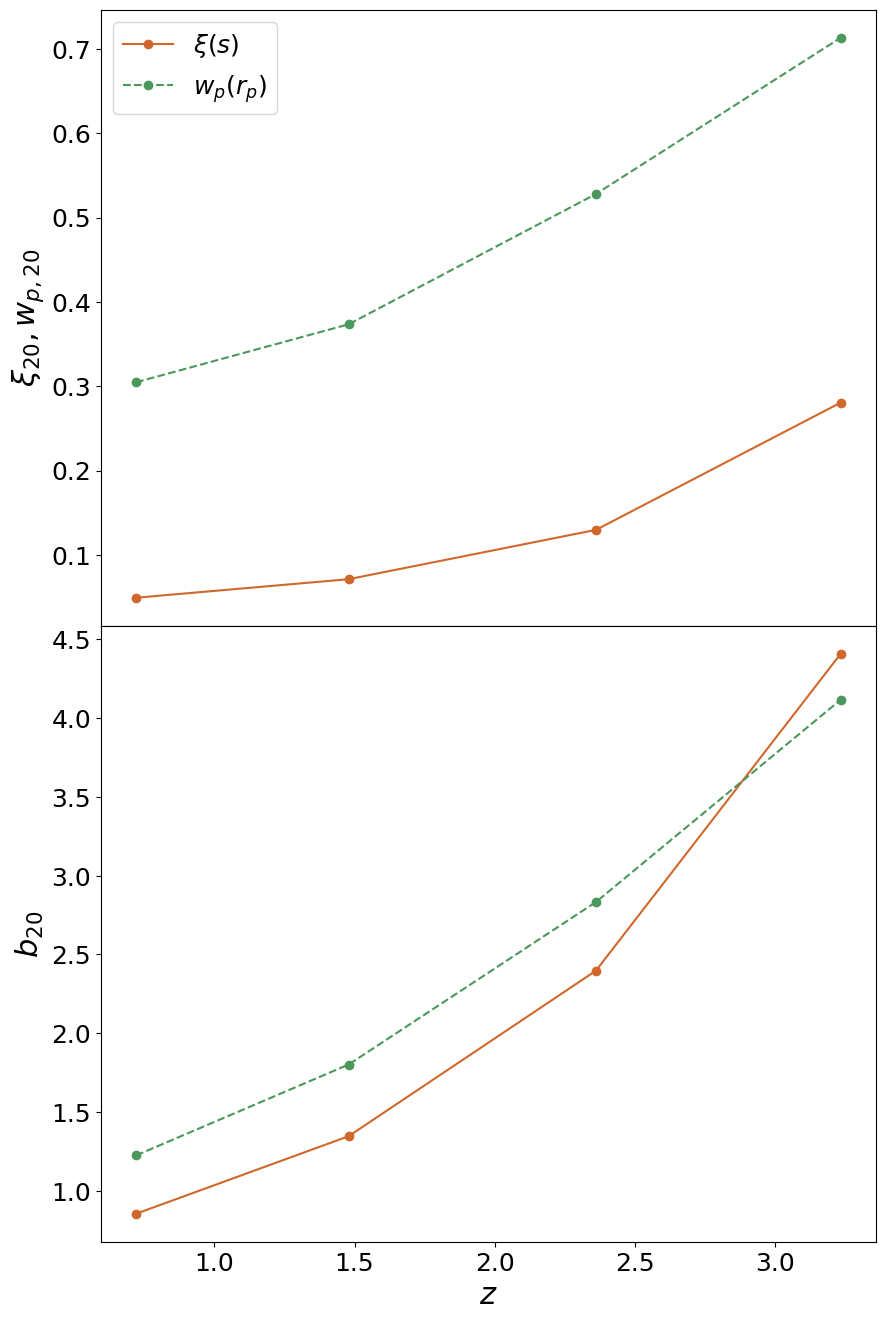

In [65]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
# for i in range(len(labels)):
    
# cf
ax1.plot(1/np.array(a_zbin)-1, cf_20, marker = 'o', label = r'$\xi(s)$', color = np.mean(cmap_qq, axis = 0))
ax2.plot(1/np.array(a_zbin)-1, bias(np.array(cf_20), cf_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1), marker = 'o',
         color = np.mean(cmap_qq, axis = 0))

# wp
ax1.plot(1/np.array(a_zbin)-1, wp_20, marker = 'o', label = '$w_p(r_p)$', color = np.mean(cmap_mm, axis = 0), linestyle = '--')
ax2.plot(1/np.array(a_zbin)-1, bias(np.array(wp_20), wp_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1), marker = 'o', 
         color = np.mean(cmap_mm, axis = 0), linestyle = '--')
ax1.legend()

# custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
# ax1.add_artist(second_legend)
        
# patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
# first_legend = ax2.legend(handles=patch, loc = 'upper left')
# ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

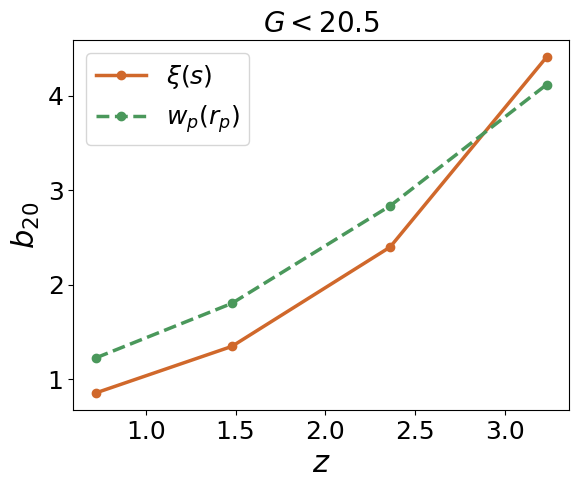

In [71]:
# fig = plt.figure(figsize = (10, 8))

# i = 1
plt.plot(1/np.array(a_zbin)-1, bias(np.array(cf_20), cf_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1), 
         marker = 'o', label = r'$\xi(s)$', color = np.mean(cmap_qq, axis = 0), linewidth = 2.5)
    
    # wp
plt.plot(1/np.array(a_zbin)-1, bias(np.array(wp_20), wp_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1),
         marker = 'o', label = '$w_p(r_p)$', color = np.mean(cmap_mm, axis = 0), linewidth = 2.5, linestyle = '--')

plt.title('$G<{}$'.format(G_hi))
plt.xlabel('$z$')
plt.ylabel('$b_{20}$')
# plt.ylim(0,10)
plt.legend()

plt.show()

In [72]:
np.save('../results/b_cf20_planck18', bias(np.array(cf_20), cf_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1))
np.save('../results/b_wp20_planck18', bias(np.array(wp_20), wp_matter_20, ccl.growth_rate(cosmo_planck18, a_zbin)-1))

In [73]:
np.save('../results/b_eff_cf20_planck18', np.sqrt(np.array(cf_20)/cf_matter_20))
np.save('../results/b_eff_wp20_planck18', np.sqrt(np.array(wp_20)/wp_matter_20))